Plot points

In [42]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.spatial import cKDTree
from scipy.stats import qmc
# =========================================================
# 1. star-shaped boundary
# =========================================================
def rQ(theta, phi):
    return np.sqrt(
        1
        + np.sin(2 * np.sin(phi) * np.cos(theta))**2
        * np.sin(2 * np.sin(phi) * np.sin(theta))**2
        * np.sin(2 * np.cos(phi))**2
    )
# =========================================================
# 2. inside test
# =========================================================
def inside_star(x, y, z, eps=1e-12):
    r = np.sqrt(x**2 + y**2 + z**2)
    theta = np.arctan2(y, x)
    phi = np.arccos(np.clip(z / (r + eps), -1, 1))
    return r <= rQ(theta, phi)

# =========================================================
# 3. generate boundary points
# =========================================================
def generate_boundary_points(N_boundary=2000):
    sampler = qmc.Halton(d=2, scramble=False)
    pts = sampler.random(N_boundary)
    theta = 2 * np.pi * pts[:, 0]
    phi = np.arccos(1 - 2 * pts[:, 1])
    r = rQ(theta, phi)
    x = r * np.sin(phi) * np.cos(theta)
    y = r * np.sin(phi) * np.sin(theta)
    z = r * np.cos(phi)
    return np.vstack([x, y, z]).T
# =========================================================
# 4. generate patch centers and H
# =========================================================
def generate_centers_auto_H(N_patch_grid, rQ, margin=0.1):
    """
    Returns
    -------
    C    : (N_patch_grid^3, 3)
    H    : scalar, max(Hx, Hy, Hz)
    """
    N_tmp = 20000
    sampler = qmc.Halton(d=2, scramble=False)
    pts = sampler.random(N_tmp)
    theta = 2.0 * np.pi * pts[:, 0]
    phi = np.arccos(1.0 - 2.0 * pts[:, 1])
    r = rQ(theta, phi)
    x = r * np.sin(phi) * np.cos(theta)
    y = r * np.sin(phi) * np.sin(theta)
    z = r * np.cos(phi)
    x_min = x.min() - margin
    x_max = x.max() + margin
    y_min = y.min() - margin
    y_max = y.max() + margin
    z_min = z.min() - margin
    z_max = z.max() + margin
    Hx = (x_max - x_min) / (N_patch_grid - 1)
    Hy = (y_max - y_min) / (N_patch_grid - 1)
    Hz = (z_max - z_min) / (N_patch_grid - 1)
    H = max(Hx, Hy, Hz)
    Cx = np.linspace(x_min, x_max, N_patch_grid)
    Cy = np.linspace(y_min, y_max, N_patch_grid)
    Cz = np.linspace(z_min, z_max, N_patch_grid)
    Xg, Yg, Zg = np.meshgrid(Cx, Cy, Cz, indexing="ij")
    C = np.vstack([Xg.ravel(), Yg.ravel(), Zg.ravel()]).T
    return C, H

def compute_R_from_H_delta(H, delta):
    return (1 + delta) * np.sqrt(3) * H / 2

# =========================================================
# 5. generate inner points via patch + filter
# =========================================================
def generate_inner_points(C, R, N_local):
    X_list = []
    for c in C:
        sampler = qmc.Halton(d=3, scramble=False)
        pts = sampler.random(N_local)
        u, v, w = pts[:, 0], pts[:, 1], pts[:, 2]
        theta = 2 * np.pi * u
        phi = np.arccos(1 - 2 * v)
        r = R * (w ** (1/3))
        x = c[0] + r * np.sin(phi) * np.cos(theta)
        y = c[1] + r * np.sin(phi) * np.sin(theta)
        z = c[2] + r * np.cos(phi)
        X_list.append(np.vstack([x, y, z]).T)
    X_raw = np.vstack(X_list)
    # ======= 关键：投影回 star domain =======
    mask = inside_star(
        X_raw[:, 0],
        X_raw[:, 1],
        X_raw[:, 2]
    )
    X_inner = X_raw[mask]
    return X_inner

def remove_empty_patches_by_Xinner(C_raw, R, X_inner):
    """
    Remove patches that contain no interior points.
    Parameters
    ----------
    C_raw : (Np, 3)
        Patch centers
    R : scalar or (Np,)
        Patch radius
    X_inner : (N, 3)
        Interior points
    Returns
    -------
    C_new : (Np_new, 3)
    R_new : (Np_new,)
    keep  : (Np,) bool mask
    nX    : (Np,) number of points inside each patch
    """
    C_raw = np.asarray(C_raw)
    X_inner = np.asarray(X_inner)
    if np.isscalar(R):
        R_vec = np.full(C_raw.shape[0], R)
    else:
        R_vec = np.asarray(R)
    tree_X = cKDTree(X_inner)
    keep = np.zeros(C_raw.shape[0], dtype=bool)
    nX = np.zeros(C_raw.shape[0], dtype=int)
    for j, c in enumerate(C_raw):
        idx = tree_X.query_ball_point(c, R_vec[j])
        nX[j] = len(idx)
        if nX[j] > 0:
            keep[j] = True
    C_new = C_raw[keep]
    R_new = R_vec[keep]
    print(f"original patches: {C_raw.shape[0]}")
    print(f"kept patches: {C_new.shape[0]}")
    print(f"removed patches: {C_raw.shape[0] - C_new.shape[0]}")
    if np.any(keep):
        print("patch nX min/mean/max:" 
              f"{nX[keep].min()} / {nX[keep].mean():.2f} / {nX[keep].max()}")
    else:
        print("No patches kept!")
    return C_new, R_new, keep, nX
# =========================================================
# 6. 可视化函数
# =========================================================
def visualize_points(X_inner, X_boundary):

    fig = plt.figure(figsize=(8, 8))
    ax = fig.add_subplot(111, projection='3d')
    # ==========================
    # 1. 生成参考边界（仅用于 wireframe）
    # ==========================
    n_theta = 60
    n_phi = 60
    theta = np.linspace(0, 2*np.pi, n_theta)
    phi = np.linspace(0, np.pi, n_phi)
    theta, phi = np.meshgrid(theta, phi)
    r = rQ(theta, phi)
    X = r * np.sin(phi) * np.cos(theta)
    Y = r * np.sin(phi) * np.sin(theta)
    Z = r * np.cos(phi)
    ax.plot_wireframe(
        X, Y, Z,
        rstride=2, cstride=2,
        color='black',
        linewidth=0.5,
        alpha=0.8,
        zorder=0.5
    )
    # ==========================
    # 2. Boundary 点
    # ==========================
    ax.scatter(
        X_boundary[:, 0],
        X_boundary[:, 1],
        X_boundary[:, 2],
        s=1,
        color='blue',
        depthshade=True,
        zorder=2,
        label='Boundary points'
    )
    # ==========================
    # 3. 内点
    # ==========================
    ax.scatter(
        X_inner[::2, 0],
        X_inner[::2, 1],
        X_inner[::2, 2],
        s=1,
        color='red',
        alpha=0.7,
        depthshade=True,
        zorder=3,
        label='Interior points'
    )
    # ==========================
    # 4. 视觉设置
    # ==========================
    ticks = [-1, -0.5, 0, 0.5, 1]
    ax.set_xticks(ticks)
    ax.set_yticks(ticks)
    ax.set_zticks(ticks)
    ax.set_xlim([-1.2, 1.2])
    ax.set_ylim([-1.2, 1.2])
    ax.set_zlim([-1.2, 1.2])
    ax.set_box_aspect([1, 1, 1])
    ax.set_xlabel('x')
    ax.set_ylabel('y')
    ax.set_zlabel('z')
    ax.grid(True, linewidth=0.4, alpha=0.3)
    ax.legend(loc='upper right', fontsize=10)
    ax.view_init(elev=35, azim=45)
    plt.tight_layout()
    plt.show()

# =========================================================
# 7. main
# =========================================================
def generator_points_3d_overlap(
    N_patch_grid,
    N_local_per_patch,
    N_boundary,
    overlap,
    visu
):

    X_boundary = generate_boundary_points(N_boundary)

    # =====================================================
    # 1. raw centers
    # =====================================================
    C_raw, H = generate_centers_auto_H(N_patch_grid, rQ, margin=0.1)
    h = H/(N_local_per_patch)**(1/3)
    info = {
        "H": H ,
        "h": h
            }

    print("Generator's C:", len(C_raw))
    # =====================================================
    # 2. compute R from overlap in 3D
    # =====================================================
    R = compute_R_from_H_delta(H, overlap) # scalar
    print("Generator's R =", R)
    # =====================================================
    # 3. inner points and filter C
    # =====================================================
    X_inner = generate_inner_points(C_raw, R, N_local_per_patch)
    C,R,_,_=remove_empty_patches_by_Xinner(C_raw, R, X_inner)
    print("X_inner:", len(X_inner))
    print("X_boundary:", len(X_boundary))
    # =====================================================
    # 5. visualization
    # =====================================================
    if visu:
        visualize_points(X_inner, X_boundary)

    return X_inner, X_boundary, C, R, info

def fill_distance(nodes):
    """
    nodes: (N, d) numpy array
    returns: scalar h = max_i min_{j != i} ||x_i - x_j||
    """
    nodes = np.asarray(nodes)
    if nodes.shape[0] <= 1:
        return 0.0
    tree = cKDTree(nodes)
    # query 2 nearest (including itself at dist 0), then take second column
    dists, _ = tree.query(nodes, k=2, workers=-1)
    # dists[:,0] == 0, so use dists[:,1]
    min_neigh = dists[:, 1]
    return np.float64(np.max(min_neigh))



Generator's C: 125
Generator's R = 0.5715535913334557
original patches: 125
kept patches: 116
removed patches: 9
patch nX min/mean/max:2 / 403.86 / 1487
X_inner: 9390
X_boundary: 100


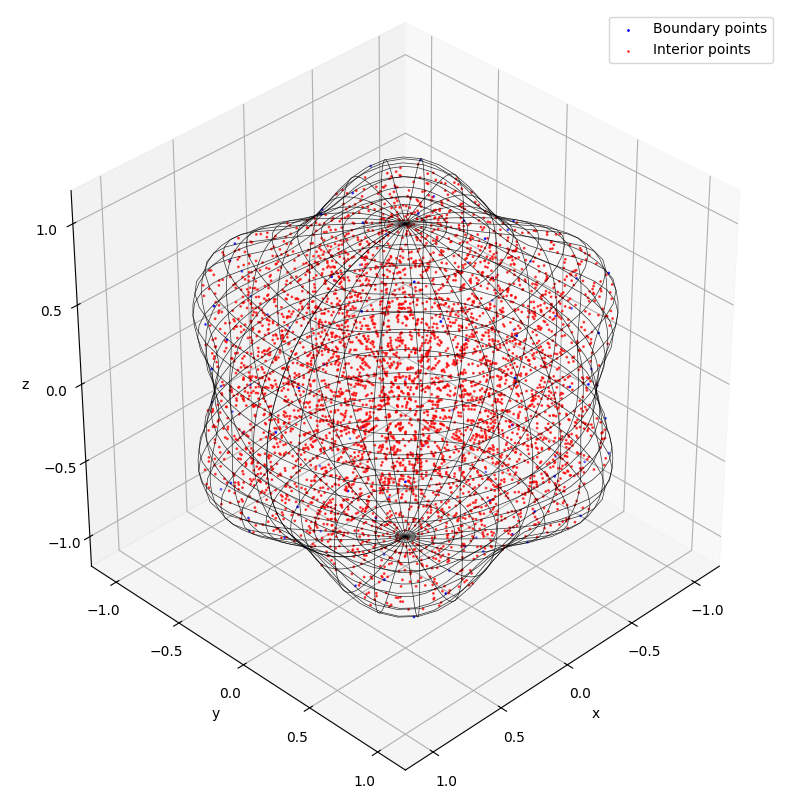

填充间距: 0.08215575579604696


In [43]:
if __name__ == "__main__":
    N_patch_grid = 5
    N_local_per_patch = 300
    N_boundary = 100
    overlap = 0.2
    visu = True
    X_inner, X_boundary, C, R, info = generator_points_3d_overlap(N_patch_grid,N_local_per_patch,N_boundary,overlap,visu)

    # dists = np.linalg.norm(X_inner[:, None, :] - X_inner[None, :, :], axis=-1)
    # h = fill_distance(X_inner)
    print("填充间距:", info['h'])



In [44]:
import numpy as np
import torch
import torch.nn as nn
import scipy.sparse as sp
import scipy.sparse.linalg as spla
from scipy.spatial import KDTree, distance
from scipy.spatial.distance import pdist, squareform
from scipy.sparse import lil_matrix
from scipy.sparse.linalg import spsolve,splu
from scipy.linalg import lstsq
from scipy.sparse import csc_matrix
import time
dtype = torch.float64
device = torch.device('cuda:1' if torch.cuda.is_available() else 'cpu')

def relative_l2(u_pred, u_true):
# Relative L2 error between two (N, 1) tensors.
    eps = 0
    def to_numpy(u):
        if sp.issparse(u):
            u = u.toarray()
        else:
            u = np.asarray(u)
        return u.reshape(-1) # flatten to (N,)
    u_pred,u_true = to_numpy(u_pred),to_numpy(u_true)
    return np.linalg.norm(u_pred - u_true) / (np.linalg.norm(u_true) + eps)


import numpy as np
from scipy.spatial import cKDTree

def fill_distance(nodes):
    """
    nodes: (N, d) numpy array
    returns: scalar h = max_i min_{j != i} ||x_i - x_j||
    """
    nodes = np.asarray(nodes)
    if nodes.shape[0] <= 1:
        return 0.0
    tree = cKDTree(nodes)
    # query 2 nearest (including itself at dist 0), then take second column
    dists, _ = tree.query(nodes, k=2, workers=-1)
    # dists[:,0] == 0, so use dists[:,1]
    min_neigh = dists[:, 1]
    return np.float64(np.max(min_neigh))

class PhiNet(nn.Module):
    def __init__(self, input_size, hidden_size, output_size):
        super(PhiNet, self).__init__()
        self.input_size = input_size
        self.hidden_size = hidden_size
        self.output_size = output_size
        self.input_layer = nn.Linear(input_size, hidden_size, bias = False)
        self.hidden_layer = nn.Linear(hidden_size, hidden_size, bias = False)
        self.output_layer = nn.Linear(hidden_size, output_size, bias = False) 
	
    def forward(self, x): # r : (K,1)  or (K,K)
        K = x.shape[0]
        if x.shape[-1] != self.input_size:
            x = x.view(-1, self.input_size)
        # output = torch.exp(-(2.043220859062252)**2 * x**2)
        output = self.input_layer(x)
        output = torch.sin(torch.pi * output)
        output = torch.cos(torch.pi * self.hidden_layer(output))
        output = self.output_layer(output)
        if output.shape[0] != K:
            output = output.view(K, -1)
        return output
    
    def initi(self):
        for m in self.modules():
            if isinstance(m, nn.Linear):
                nn.init.xavier_normal_(m.weight)
                if m.bias is not None:
                    nn.init.uniform_(m.bias, 0, 0)
                    # nn.init.uniform_(m.bias, -torch.pi, -torch.pi)

def dphi_wrt_y_3d_batch(phi_net, y, X, eps=1e-8):
    """
    1D Parameters
    ----------
    y : (n_j,3) or (1,3)
    X : (K,3)
    
    Returns
    -------
    phi_vals : (n_j, K)
    dphi_dy  : (n_j, K)
    d2phi_dy2: (n_j, K)
    """
    y = torch.tensor(y, dtype=torch.float64, device=device)
    X = torch.tensor(X, dtype=torch.float64, device=device)
    # print("y.shape", y.shape, "X.shape", X.shape)

    # =========================================================
    # 1. pairwise difference and Euclidean distance
    # =========================================================
    diff = y[:, None, :] - X[None, :, :]          # (n_j, K, 3)
    r = torch.sqrt((diff ** 2).sum(dim=-1))  # (n_j, K)
    r = r.clamp(min=eps)  
    r.requires_grad_(True)
    # -------- forward --------
    phi_vals = phi_net(r)         # (n_j, K)

    # -------- φ'(r) --------
    dphi_dr = torch.autograd.grad(
        outputs=phi_vals,
        inputs=r,
        grad_outputs=torch.ones_like(phi_vals),
        create_graph=True
    )[0]   # (n_j, K)
    grad_phi = dphi_dr[..., None] * diff / (r[..., None])
    # -------- φ''(r) --------
    d2phi_dr2 = torch.autograd.grad(
        outputs=dphi_dr,
        inputs=r,
        grad_outputs=torch.ones_like(dphi_dr),
        create_graph=False
    )[0]   # (n_j, K)
    # 3d laplace
    lap_phi = d2phi_dr2 + (2.0 / (r)) * dphi_dr

    return (
        phi_vals.detach().cpu().numpy(),
        grad_phi.detach().cpu().numpy(),
        lap_phi.detach().cpu().numpy()
    )

def poly3D(Z, order):
    """
    Z: (K, d)
    P: (K, Norder); 
    """
    K = Z.shape[0]
    Norder = (order + 1) * (order + 2) * (order + 3) // 6
    P = np.zeros((K, Norder))
    powers = np.arange(order + 1)
    X_pow = Z[:, 0:1] ** powers
    Y_pow = Z[:, 1:2] ** powers
    Z_pow = Z[:, 2:3] ** powers
    cnt = 0
    for i in range(order + 1):
        for j in range(order - i + 1):
            for k in range(order - i - j + 1):
                P[:, cnt] = X_pow[:, i] * Y_pow[:, j] * Z_pow[:, k]
                cnt += 1        
    return P

def laplacian_poly3D(y, order):
    """
    y: (Np, d)
    lap: (Norder, Np); 
    """
    Np = y.shape[0]
    Norder = (order + 1) * (order + 2) * (order + 3) // 6
    lap = np.zeros((Norder, Np))
    
    # 【核心优化】：同样预先计算 0 到 order 的所有幂次
    powers = np.arange(order + 1)
    X_pow = y[:, 0:1] ** powers
    Y_pow = y[:, 1:2] ** powers
    Z_pow = y[:, 2:3] ** powers
    curr = 0
    for i in range(order + 1):
        for j in range(order - i + 1):
            for k in range(order - i - j + 1):
                val = np.zeros(Np)
                if i >= 2:
                    val += (i * (i - 1)) * (X_pow[:, i - 2] * Y_pow[:, j] * Z_pow[:, k])
                if j >= 2:
                    val += (j * (j - 1)) * (X_pow[:, i] * Y_pow[:, j - 2] * Z_pow[:, k])
                if k >= 2:
                    val += (k * (k - 1)) * (X_pow[:, i] * Y_pow[:, j] * Z_pow[:, k - 2]) 
                lap[curr, :] = val
                curr += 1     
    return lap

def rfm_fd_solve_helmholtz_3d(X, Yin, Yb, f_func, g_func,Phi, reg, K):
    """
    -Laplace(u) - k^2 u = f, where k^2 = 1
    X:  (N,3)  RBF source points
    Yin: (M1,3) interior points
    Yb:  (M2,3) boundary points
    f_func, g_func: Python callable returning torch tensor
    K: number of neighbors
    order: 0,1,2,3...
    """
    N = X.shape[0]
    M1 = Yin.shape[0]
    M2 = Yb.shape[0]
    M = M1 + M2
    Y = np.vstack((Yin, Yb))

    tree = KDTree(X)
    dist, idx = tree.query(Y, k=K, workers=-1)
    
    f_val =f_func(Yin[:, 0], Yin[:, 1], Yin[:, 2])  if callable(f_func) else f_func #(M1,)
    g_val = g_func(Yb[:, 0], Yb[:, 1], Yb[:, 2]) if callable(g_func) else g_func
    RHS = np.concatenate((f_val, g_val)) #(M,)
    # print("RHS.shape",RHS.shape)
    L = lil_matrix((M, N))
    LI = lil_matrix((M, N))
    # ==============================
    # main loop
    # ==============================
    diff_XX = X[:,None,:] - X[None,:,:]
    dist_XX = np.sqrt((diff_XX**2).sum(-1)) # (N,N)
    start = time.time()
    for i in range(M):
        y = Y[i, :][None,:]
        idx_l = idx[i, :]
        Z = X[idx_l, :]
        dist_ZZ = dist_XX[np.ix_(idx_l,idx_l)]
        dist_ZZ = torch.as_tensor(dist_ZZ, dtype = torch.float64, device = device)
        Phi_jj = Phi(dist_ZZ)
        Phi_jj = Phi_jj.detach().cpu().numpy()
        phi_xj, grad_phi, lap_phi  = dphi_wrt_y_3d_batch(Phi, y, Z, eps=1e-8) # (1,K),(1,K,3),(1,K),
        # print("phi_xj",phi_xj.shape,"lap_phi",lap_phi.shape, "grad_phi",grad_phi.shape)
        # AP
        AP = Phi_jj
        # AP += reg * np.eye(K + Norder)
        # AP += reg * np.eye(K)
        
        # RHS_lap, RHS_ide
        RHS_lap = (lap_phi.squeeze(0))[:,None]  # (K,1)
        # print(RHS_lap.shape)
        RHS_ide = (phi_xj.squeeze(0))[:,None]   # (K,1)
        RHS_all = np.concatenate((RHS_lap, RHS_ide),axis=1)       # (K,2)
        #
        # w_all = np.linalg.solve(AP, RHS_all).T                    # (2, K)
        w_all = lstsq(AP, RHS_all, cond=None)[0].T
        w_lap = w_all[0, :]
        w_ide = w_all[1, :]
        
        if i < M1: 
            L[i, idx_l] = -w_lap - w_ide
            LI[i, idx_l] = w_ide
        else:
            L[i, idx_l] = w_ide
            LI[i, idx_l] = w_ide

    end = time.time()
    print("Compile derivative matrix time =", end - start, "seconds")
        
    L = L.tocsc()
    LI = LI.tocsc()
    # ==============================
    # solve
    # ==============================
    if M == N:
        LU = splu(L, permc_spec='COLAMD')
        UX = LU.solve(RHS)
    else:
        L_dense = L.toarray()
        UX, res, rank, s = lstsq(L_dense, RHS)
        print(f'rank = {rank}')
    res = L @ UX - RHS
    # print("boundary residual:", np.max(np.abs(res[M1:]))) # 1e-10
    UY = LI @ UX

    return UY[:,None],LI,L
# (M,1)



def rfm_fd_poly_solve_helmholtz_3d(X, Yin, Yb, f_func, g_func,Phi, reg, K, order):
    """
    -Laplace(u) - k^2 u = f, where k^2 = 1
    X:  (N,3)  RBF source points
    Yin: (M1,3) interior points
    Yb:  (M2,3) boundary points
    f_func, g_func: Python callable returning torch tensor
    K: number of neighbors
    order: 0,1,2,3...
    """
    N = X.shape[0]
    M1 = Yin.shape[0]
    M2 = Yb.shape[0]
    M = M1 + M2
    Y = np.vstack((Yin, Yb))
    Norder = (order + 1) * (order + 2) * (order + 3) // 6

    tree = KDTree(X)
    dist, idx = tree.query(Y, k=K, workers=-1)
    
    f_val =f_func(Yin[:, 0], Yin[:, 1], Yin[:, 2])  if callable(f_func) else f_func #(M1,)
    g_val = g_func(Yb[:, 0], Yb[:, 1], Yb[:, 2]) if callable(g_func) else g_func
    RHS = np.concatenate((f_val, g_val)) #(M,)
    # print("RHS.shape",RHS.shape)
    L = lil_matrix((M, N))
    LI = lil_matrix((M, N))
    O = np.zeros((Norder,Norder))
    # ==============================
    # main loop
    # ==============================
    diff_XX = X[:,None,:] - X[None,:,:]
    dist_XX = np.sqrt((diff_XX**2).sum(-1)) # (N,N)
    start = time.time()
    for i in range(M):
        y = Y[i, :][None,:]
        idx_l = idx[i, :]
        Z = X[idx_l, :]
        dist_ZZ = dist_XX[np.ix_(idx_l,idx_l)]
        dist_ZZ = torch.as_tensor(dist_ZZ, dtype = torch.float64, device = device)
        Phi_jj = Phi(dist_ZZ)
        Phi_jj = Phi_jj.detach().cpu().numpy()
        phi_xj, grad_phi, lap_phi  = dphi_wrt_y_3d_batch(Phi, y, Z, eps=1e-8) # (1,K),(1,K,3),(1,K),
        # print("phi_xj",phi_xj.shape,"lap_phi",lap_phi.shape, "grad_phi",grad_phi.shape)
        # AP
        P = poly3D(Z, order) # (K,Norder)
        AP = np.block([
            [Phi_jj, P],
            [P.T, O]
        ])
        # AP += reg * np.eye(K + Norder)
        # AP[:K,:K] += reg * np.eye(K)
        
        # RHS_lap, RHS_ide
        p_y = poly3D(y, order)               # (1,Norder)
        lap_p = laplacian_poly3D(y, order)   # (Norder,1)
        # print("p_y.shape",p_y.shape, "lap_p",lap_p.shape)
        RHS_lap = np.concatenate((lap_phi, lap_p.T), axis = 1).T  # (K+Norder,1)
        # print(RHS_lap.shape)
        RHS_ide = np.concatenate((phi_xj, p_y), axis = 1).T       # (K+Norder,1)
        RHS_all = np.concatenate((RHS_lap, RHS_ide),axis=1)       # (K+Norder,2)
        #
        # w_all = np.linalg.solve(AP, RHS_all).T                    # (2, K+Norder)
        w_all = lstsq(AP, RHS_all, cond=None)[0].T
        w_lap = w_all[0, :]
        w_ide = w_all[1, :]
        
        if i < M1: 
            L[i, idx_l] = -w_lap[:K] - w_ide[:K]
            LI[i, idx_l] = w_ide[:K]
        else:
            L[i, idx_l] = w_ide[:K]
            LI[i, idx_l] = w_ide[:K]

    end = time.time()
    print("Compile derivative matrix time =", end - start, "seconds")
        
    L = L.tocsc()
    LI = LI.tocsc()
    # ==============================
    # solve
    # ==============================
    if M == N:
        LU = splu(L, permc_spec='COLAMD')
        UX = LU.solve(RHS)
    else:
        L_dense = L.toarray()
        UX, res, rank, s = lstsq(L_dense, RHS)
        print(f'rank = {rank}')
    res = L @ UX - RHS
    # print("boundary residual:", np.max(np.abs(res[M1:]))) # 1e-10
    UY = LI @ UX

    return UY[:,None],LI,L
# (M,1)

In [45]:
key = 100
np.random.seed(key)
torch.manual_seed(key)
torch.cuda.manual_seed_all(key)

hidden_size = 50
Phi = PhiNet(input_size=1, hidden_size=hidden_size, output_size=1).to(device) #
Phi.initi()
Phi = Phi.double()
# # ===========================================================
u_func = lambda x, y, z: np.sin(np.pi * x) * np.sin(np.pi * y) * np.sin(np.pi * z)
f_func = lambda x, y, z: (3 * np.pi**2 - 1) * np.sin(np.pi * x) * np.sin(np.pi * y) * np.sin(np.pi * z)
g_func = lambda x, y, z: u_func(x, y, z)

# #===========================================================
# #=================== generate points =======================
# #===========================================================
torchdtype = torch.float64
N_patch_grid = 5
N_local_per_patch = 100
N_boundary = 2500
overlap = 0.2
X_inner, X_boundary, C, R, info = generator_points_3d_overlap(
        N_patch_grid,
        N_local_per_patch,
        N_boundary,
        overlap,
        False
    )
X = np.vstack([X_inner, X_boundary])
Yin = X_inner
M1 = X_inner.shape[0]
Yb = X_boundary
Y = np.vstack([Yin, Yb])
K = 150
reg = 1e-13
order = 1
u_true = u_func(Y[:,0:1], Y[:,1:2],Y[:,2:3])

# # ===========================================================
start = time.time()
UY,LI,L = rfm_fd_poly_solve_helmholtz_3d(X, Yin, Yb, f_func, g_func,Phi, reg, K, order)
end = time.time()
print("Time for solving Helm =", end - start, "seconds")

print(u_true.shape,UY.shape)
error = np.abs(UY - u_true)
# print("boundary error is", error[M1:].max())
print(f'p = {order}; L infity error in u_rfmfd: {error.max().item():.3e}')
error_u = relative_l2(UY ,u_true)
print(f'p = {order}; Relative L2 error in u_rfmfd: {error_u.item():.3e}')




Generator's C: 125
Generator's R = 0.5715535913334557
original patches: 125
kept patches: 111
removed patches: 14
patch nX min/mean/max:1 / 139.59 / 497
X_inner: 3101
X_boundary: 2500
Compile derivative matrix time = 18.461358785629272 seconds
Time for solving Helm = 22.311267375946045 seconds
(5601, 1) (5601, 1)
p = 1; L infity error in u_rfmfd: 2.267e-04
p = 1; Relative L2 error in u_rfmfd: 5.821e-05


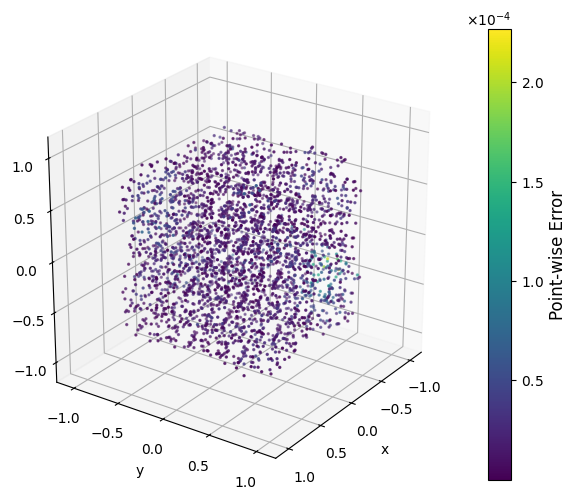

In [46]:

import matplotlib.ticker as ticker
fig = plt.figure(figsize=(6,5))
ax = fig.add_subplot(111, projection='3d')
ticks = [-1, -0.5, 0, 0.5, 1]
ax.set_xticks(ticks)
ax.set_yticks(ticks)
ax.set_zticks(ticks)
ax.set_xlim([-1.2, 1.2])
ax.set_ylim([-1.2, 1.2])
ax.set_zlim([-1.2, 1.2])
ax.set_box_aspect([1, 1, 1])
sc = ax.scatter(
    Y[:M1, 0], Y[:M1, 1], Y[:M1, 2],
    c=error[:M1,:],
    cmap='viridis',
    s=2
)
cbar = plt.colorbar(sc)
cbar.set_label('Point-wise Error', fontsize=12)
formatter = ticker.ScalarFormatter(useMathText=True)
formatter.set_scientific(True)
formatter.set_powerlimits((0, 0))
cbar.ax.yaxis.set_major_formatter(formatter)
plt.xlabel('x')
plt.ylabel('y')
ax.set_zlabel('z')
ax.view_init(elev=25, azim=35)
plt.tight_layout()
plt.show()

In [47]:
key = 100
np.random.seed(key)

NN = [20, 30, 100, 200,]
BC = [600,800,2200,4000,]
KK = [50, 80, 200, 300]
RR = [1e-12,1e-12,1e-13,1e-13]

start_order = 0
end_order = 5
Length = end_order-start_order
H = np.zeros((Length,len(NN)))
E = np.zeros((Length,len(NN)))


Run Q=1, N_local_per_patch=20
Generator's C: 125
Generator's R = 0.5715535913334557
original patches: 125
kept patches: 102
removed patches: 23
patch nX min/mean/max:1 / 29.54 / 97
X_inner: 620
X_boundary: 600
fill distance is 0.20261351691995652


Compile derivative matrix time = 1.1875009536743164 seconds
p = 0; L infity error in u_rfmfd: 1.465e-02
Run Q=2, N_local_per_patch=30
Generator's C: 125
Generator's R = 0.5715535913334557
original patches: 125
kept patches: 104
removed patches: 21
patch nX min/mean/max:1 / 44.52 / 149
X_inner: 927
X_boundary: 800
fill distance is 0.17699921027279156
Compile derivative matrix time = 2.3801157474517822 seconds
p = 0; L infity error in u_rfmfd: 8.860e-03
Run Q=3, N_local_per_patch=100
Generator's C: 125
Generator's R = 0.5715535913334557
original patches: 125
kept patches: 111
removed patches: 14
patch nX min/mean/max:1 / 139.59 / 497
X_inner: 3101
X_boundary: 2200
fill distance is 0.1184891034951291
Compile derivative matrix time = 20.99656629562378 seconds
p = 0; L infity error in u_rfmfd: 4.455e-04
Run Q=4, N_local_per_patch=200
Generator's C: 125
Generator's R = 0.5715535913334557
original patches: 125
kept patches: 116
removed patches: 9
patch nX min/mean/max:1 / 269.78 / 993
X_inner

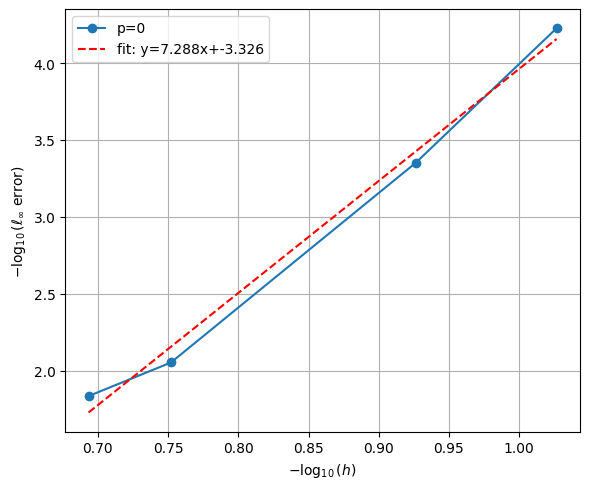

In [48]:
key = 100
np.random.seed(key)

NN = [20, 30, 100, 200,]
BC = [600,800,2200,4000,]
KK = [50, 80, 180, 300]

RR = [1e-12,1e-12,1e-13,1e-14]

order = 0
for qi, n_local in enumerate(NN):
    print(f'Run Q={qi+1}, N_local_per_patch={n_local}')
    N_patch_grid = 5
    N_local_per_patch = NN[qi]
    N_boundary = BC[qi]
    overlap = 0.2

    # generate points
    X_inner, X_boundary, C, R, info = generator_points_3d_overlap(
            N_patch_grid,
            N_local_per_patch,
            N_boundary,
            overlap,
            False
        )
    X = np.vstack([X_inner, X_boundary])
    Yin = X_inner
    Yb = X_boundary
    Y = np.vstack([Yin, Yb])
    print("fill distance is", info["h"])
    K = KK[qi]
    reg = RR[qi]
    u_true = u_func(Y[:,0:1], Y[:,1:2],Y[:,2:3])
    if order == 0 :
        UY,LI,L = rfm_fd_solve_helmholtz_3d(X, Yin, Yb, f_func, g_func,Phi, reg, K)
    else:
        UY,LI,L = rfm_fd_poly_solve_helmholtz_3d(X, Yin, Yb, f_func, g_func,Phi, reg, K, order)
    error = np.max(np.abs(UY - u_true))
    print(f'p = {order}; L infity error in u_rfmfd: {error.item():.3e}')
    # error_l2 = np.sqrt(np.mean((UY - u_true)**2))
    # print(f'p = {order}; L2 error in u_rfmfd: {error_l2.item():.3e}')
    E[order-start_order,qi] = error
    H[order-start_order,qi] = info["h"]


row = order - start_order
x = -np.log10(H[row, :])
y = -np.log10(E[row, :])
mask = np.isfinite(x) & np.isfinite(y) & (H[row, :] > 0) & (E[row, :] > 0)
if np.count_nonzero(mask) >= 2:
    slope, intercept = np.polyfit(x[mask], y[mask], 1)
    print(f'slope = {slope:.6f}, bias = {intercept:.6f}')
    xx = np.linspace(x[mask].min(), x[mask].max(), 100)
    yy = slope * xx + intercept
    plt.figure(figsize=(6, 5))
    plt.plot(x[mask], y[mask], marker='o', linestyle='-', label=f'p={order}')
    plt.plot(xx, yy, 'r--', label=f'fit: y={slope:.3f}x+{intercept:.3f}')
    plt.xlabel(r'$-\log_{10}(h)$')
    plt.ylabel(r'$-\log_{10}(\ell_{\infty}\ \mathrm{error})$')
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.show()

Run Q=1, N_local_per_patch=20
Generator's C: 125
Generator's R = 0.5715535913334557
original patches: 125
kept patches: 102
removed patches: 23
patch nX min/mean/max:1 / 29.54 / 97
X_inner: 620
X_boundary: 600
fill distance is 0.20261351691995652
Compile derivative matrix time = 1.4528627395629883 seconds
p = 1; L infity error in u_rfmfd: 2.013e-02
Run Q=2, N_local_per_patch=30
Generator's C: 125
Generator's R = 0.5715535913334557
original patches: 125
kept patches: 104
removed patches: 21
patch nX min/mean/max:1 / 44.52 / 149
X_inner: 927
X_boundary: 800
fill distance is 0.17699921027279156
Compile derivative matrix time = 2.6383724212646484 seconds
p = 1; L infity error in u_rfmfd: 7.128e-03
Run Q=3, N_local_per_patch=100
Generator's C: 125
Generator's R = 0.5715535913334557
original patches: 125
kept patches: 111
removed patches: 14
patch nX min/mean/max:1 / 139.59 / 497
X_inner: 3101
X_boundary: 2200
fill distance is 0.1184891034951291
Compile derivative matrix time = 35.2143466472

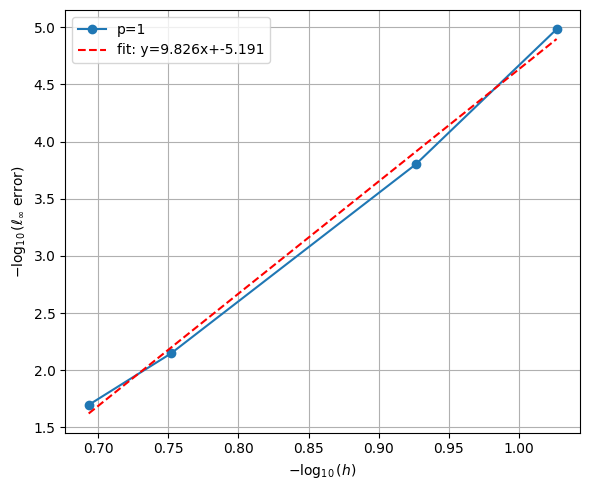

In [49]:
key = 100
np.random.seed(key)


NN = [20, 30, 100, 200 ]
BC = [600,800,2200,4000]
KK = [50, 80, 240, 305]


RR = [1e-12,1e-12,1e-13,1e-13]

order = 1
for qi, n_local in enumerate(NN):
    print(f'Run Q={qi+1}, N_local_per_patch={n_local}')
    N_patch_grid = 5
    N_local_per_patch = NN[qi]
    N_boundary = BC[qi]
    overlap = 0.2

    # generate points
    X_inner, X_boundary, C, R, info = generator_points_3d_overlap(
            N_patch_grid,
            N_local_per_patch,
            N_boundary,
            overlap,
            False
        )
    X = np.vstack([X_inner, X_boundary])
    Yin = X_inner
    Yb = X_boundary
    Y = np.vstack([Yin, Yb])
    print("fill distance is", info["h"])
    K = KK[qi]
    reg = RR[qi]
    u_true = u_func(Y[:,0:1], Y[:,1:2],Y[:,2:3])
    UY,LI,L = rfm_fd_poly_solve_helmholtz_3d(X, Yin, Yb, f_func, g_func,Phi, reg, K, order)
    error = np.max(np.abs(UY - u_true))
    print(f'p = {order}; L infity error in u_rfmfd: {error.item():.3e}')
    # error_l2 = np.sqrt(np.mean((UY - u_true)**2))
    # print(f'p = {order}; L2 error in u_rfmfd: {error_l2.item():.3e}')
    E[order-start_order,qi] = error
    H[order-start_order,qi] = info["h"]

row = order - start_order
x = -np.log10(H[row, :])
y = -np.log10(E[row, :])
mask = np.isfinite(x) & np.isfinite(y) & (H[row, :] > 0) & (E[row, :] > 0)
if np.count_nonzero(mask) >= 2:
    slope, intercept = np.polyfit(x[mask], y[mask], 1)
    print(f'slope = {slope:.6f}, bias = {intercept:.6f}')
    xx = np.linspace(x[mask].min(), x[mask].max(), 100)
    yy = slope * xx + intercept
    plt.figure(figsize=(6, 5))
    plt.plot(x[mask], y[mask], marker='o', linestyle='-', label=f'p={order}')
    plt.plot(xx, yy, 'r--', label=f'fit: y={slope:.3f}x+{intercept:.3f}')
    plt.xlabel(r'$-\log_{10}(h)$')
    plt.ylabel(r'$-\log_{10}(\ell_{\infty}\ \mathrm{error})$')
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.show()

Run Q=1, N_local_per_patch=20
Generator's C: 125
Generator's R = 0.5715535913334557
original patches: 125
kept patches: 102
removed patches: 23
patch nX min/mean/max:1 / 29.54 / 97
X_inner: 620
X_boundary: 600
fill distance is 0.20261351691995652
Compile derivative matrix time = 1.2014915943145752 seconds
p = 2; L infity error in u_rfmfd: 3.900e-02
Run Q=2, N_local_per_patch=30
Generator's C: 125
Generator's R = 0.5715535913334557
original patches: 125
kept patches: 104
removed patches: 21
patch nX min/mean/max:1 / 44.52 / 149
X_inner: 927
X_boundary: 800
fill distance is 0.17699921027279156
Compile derivative matrix time = 2.422459840774536 seconds
p = 2; L infity error in u_rfmfd: 8.666e-03
Run Q=3, N_local_per_patch=100
Generator's C: 125
Generator's R = 0.5715535913334557
original patches: 125
kept patches: 111
removed patches: 14
patch nX min/mean/max:1 / 139.59 / 497
X_inner: 3101
X_boundary: 2200
fill distance is 0.1184891034951291
Compile derivative matrix time = 37.39475846290

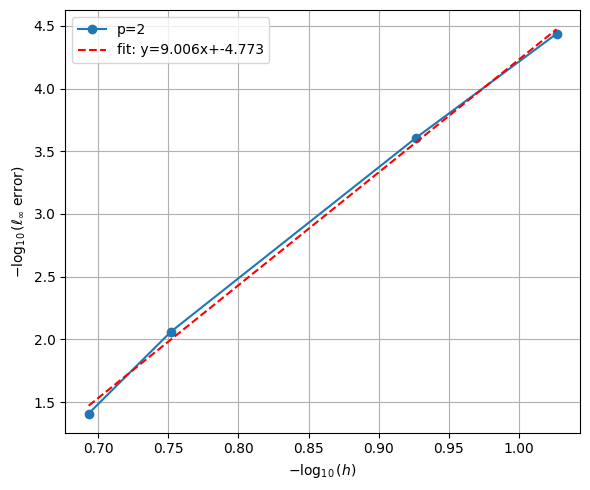

In [50]:
key = 100
np.random.seed(key)

# NN = [20, 30, 100, 200,]
# BC = [600,800,3000,4200,]

NN = [20, 30, 100, 200 ]
BC = [600,800,2200,4000]

KK = [35, 70, 240, 360]
RR = [1e-12,1e-12,1e-13,1e-13]


order = 2
for qi, n_local in enumerate(NN):
    print(f'Run Q={qi+1}, N_local_per_patch={n_local}')
    N_patch_grid = 5
    N_local_per_patch = NN[qi]
    N_boundary = BC[qi]
    overlap = 0.2

    # generate points
    X_inner, X_boundary, C, R, info = generator_points_3d_overlap(
            N_patch_grid,
            N_local_per_patch,
            N_boundary,
            overlap,
            False
        )
    X = np.vstack([X_inner, X_boundary])
    Yin = X_inner
    Yb = X_boundary
    Y = np.vstack([Yin, Yb])
    print("fill distance is", info["h"])
    K = KK[qi]
    reg = RR[qi]
    u_true = u_func(Y[:,0:1], Y[:,1:2],Y[:,2:3])
    if order == 0 :
        UY,LI,L = rfm_fd_solve_helmholtz_3d(X, Yin, Yb, f_func, g_func,Phi, reg, K)
    else:
        UY,LI,L = rfm_fd_poly_solve_helmholtz_3d(X, Yin, Yb, f_func, g_func,Phi, reg, K, order)
    error = np.max(np.abs(UY - u_true))
    print(f'p = {order}; L infity error in u_rfmfd: {error.item():.3e}')
    # error_l2 = np.sqrt(np.mean((UY - u_true)**2))
    # print(f'p = {order}; L2 error in u_rfmfd: {error_l2.item():.3e}')
    E[order-start_order,qi] = error
    H[order-start_order,qi] = info["h"]


row = order - start_order
x = -np.log10(H[row, :])
y = -np.log10(E[row, :])
mask = np.isfinite(x) & np.isfinite(y) & (H[row, :] > 0) & (E[row, :] > 0)
if np.count_nonzero(mask) >= 2:
    slope, intercept = np.polyfit(x[mask], y[mask], 1)
    print(f'slope = {slope:.6f}, bias = {intercept:.6f}')
    xx = np.linspace(x[mask].min(), x[mask].max(), 100)
    yy = slope * xx + intercept
    plt.figure(figsize=(6, 5))
    plt.plot(x[mask], y[mask], marker='o', linestyle='-', label=f'p={order}')
    plt.plot(xx, yy, 'r--', label=f'fit: y={slope:.3f}x+{intercept:.3f}')
    plt.xlabel(r'$-\log_{10}(h)$')
    plt.ylabel(r'$-\log_{10}(\ell_{\infty}\ \mathrm{error})$')
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.show()

Run Q=1, N_local_per_patch=20
Generator's C: 125
Generator's R = 0.5715535913334557
original patches: 125
kept patches: 102
removed patches: 23
patch nX min/mean/max:1 / 29.54 / 97
X_inner: 620
X_boundary: 600
fill distance is 0.20261351691995652
Compile derivative matrix time = 1.8983852863311768 seconds
p = 3; L infity error in u_rfmfd: 3.803e-02
Run Q=2, N_local_per_patch=30
Generator's C: 125
Generator's R = 0.5715535913334557
original patches: 125
kept patches: 104
removed patches: 21
patch nX min/mean/max:1 / 44.52 / 149
X_inner: 927
X_boundary: 800
fill distance is 0.17699921027279156
Compile derivative matrix time = 3.647859811782837 seconds
p = 3; L infity error in u_rfmfd: 8.924e-03
Run Q=3, N_local_per_patch=100
Generator's C: 125
Generator's R = 0.5715535913334557
original patches: 125
kept patches: 111
removed patches: 14
patch nX min/mean/max:1 / 139.59 / 497
X_inner: 3101
X_boundary: 2200
fill distance is 0.1184891034951291
Compile derivative matrix time = 23.14110565185

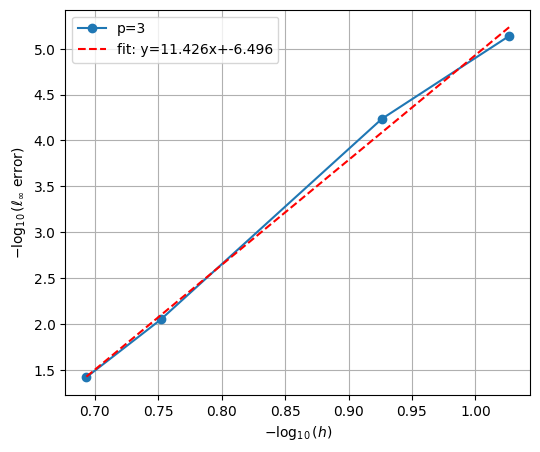

In [51]:
key = 100
np.random.seed(key)

NN = [20, 30, 100, 200,]
BC = [600,800,2200,4000,]
KK = [65,90,180,400]
RR = [1e-12,1e-12,1e-14,1e-14]

order = 3
for qi, n_local in enumerate(NN):
    print(f'Run Q={qi+1}, N_local_per_patch={n_local}')
    N_patch_grid = 5
    N_local_per_patch = NN[qi]
    N_boundary = BC[qi]
    overlap = 0.2

    # generate points
    X_inner, X_boundary, C, R, info = generator_points_3d_overlap(
            N_patch_grid,
            N_local_per_patch,
            N_boundary,
            overlap,
            False
        )
    X = np.vstack([X_inner, X_boundary])
    Yin = X_inner
    Yb = X_boundary
    Y = np.vstack([Yin, Yb])
    print("fill distance is", info["h"])
    K = KK[qi]
    reg = RR[qi]
    u_true = u_func(Y[:,0:1], Y[:,1:2],Y[:,2:3])
    if order == 0 :
        UY,LI,L = rfm_fd_solve_helmholtz_3d(X, Yin, Yb, f_func, g_func,Phi, reg, K)
    else:
        UY,LI,L = rfm_fd_poly_solve_helmholtz_3d(X, Yin, Yb, f_func, g_func,Phi, reg, K, order)
    error = np.max(np.abs(UY - u_true))
    print(f'p = {order}; L infity error in u_rfmfd: {error.item():.3e}')
    # error_l2 = np.sqrt(np.mean((UY - u_true)**2))
    # print(f'p = {order}; L2 error in u_rfmfd: {error_l2.item():.3e}')
    E[order-start_order,qi] = error
    H[order-start_order,qi] = info["h"]


row = order - start_order
x = -np.log10(H[row, :])
y = -np.log10(E[row, :])
mask = np.isfinite(x) & np.isfinite(y) & (H[row, :] > 0) & (E[row, :] > 0)
if np.count_nonzero(mask) >= 2:
    slope, intercept = np.polyfit(x[mask], y[mask], 1)
    print(f'slope = {slope:.6f}, bias = {intercept:.6f}')
    xx = np.linspace(x[mask].min(), x[mask].max(), 100)
    yy = slope * xx + intercept
    plt.figure(figsize=(6, 5))
    plt.plot(x[mask], y[mask], marker='o', linestyle='-', label=f'p={order}')
    plt.plot(xx, yy, 'r--', label=f'fit: y={slope:.3f}x+{intercept:.3f}')
    plt.xlabel(r'$-\log_{10}(h)$')
    plt.ylabel(r'$-\log_{10}(\ell_{\infty}\ \mathrm{error})$')
    plt.legend()
    plt.grid(True)
    plt.show()

Run Q=1, N_local_per_patch=20
Generator's C: 125
Generator's R = 0.5715535913334557
original patches: 125
kept patches: 102
removed patches: 23
patch nX min/mean/max:1 / 29.54 / 97
X_inner: 620
X_boundary: 600
fill distance is 0.20261351691995652
Compile derivative matrix time = 2.249724864959717 seconds
p = 4; L infity error in u_rfmfd: 2.088e-02
Run Q=2, N_local_per_patch=30
Generator's C: 125
Generator's R = 0.5715535913334557
original patches: 125
kept patches: 104
removed patches: 21
patch nX min/mean/max:1 / 44.52 / 149
X_inner: 927
X_boundary: 800
fill distance is 0.17699921027279156
Compile derivative matrix time = 4.053264856338501 seconds
p = 4; L infity error in u_rfmfd: 3.560e-03
Run Q=3, N_local_per_patch=100
Generator's C: 125
Generator's R = 0.5715535913334557
original patches: 125
kept patches: 111
removed patches: 14
patch nX min/mean/max:1 / 139.59 / 497
X_inner: 3101
X_boundary: 2200
fill distance is 0.1184891034951291
Compile derivative matrix time = 27.607080459594

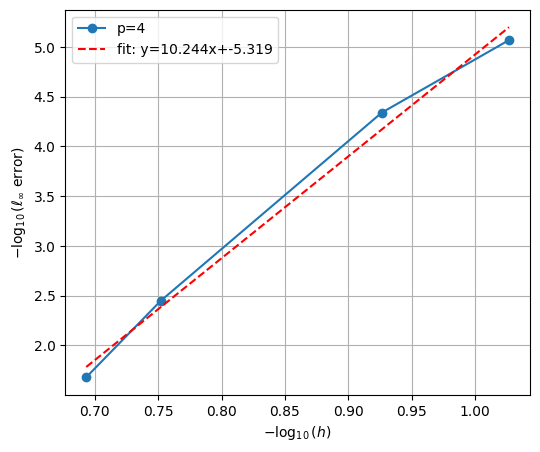

In [52]:
key = 100
np.random.seed(key)


NN = [20, 30, 100, 200,]
BC = [600,800,2200,4000,]
KK = [65,85,180,400]
RR = [1e-12,1e-12,1e-15,1e-15]

order = 4
for qi, n_local in enumerate(NN):
    print(f'Run Q={qi+1}, N_local_per_patch={n_local}')
    N_patch_grid = 5
    N_local_per_patch = NN[qi]
    N_boundary = BC[qi]
    overlap = 0.2

    # generate points
    X_inner, X_boundary, C, R, info = generator_points_3d_overlap(
            N_patch_grid,
            N_local_per_patch,
            N_boundary,
            overlap,
            False
        )
    X = np.vstack([X_inner, X_boundary])
    Yin = X_inner
    Yb = X_boundary
    Y = np.vstack([Yin, Yb])
    print("fill distance is", info["h"])
    K = KK[qi]
    reg = RR[qi]
    u_true = u_func(Y[:,0:1], Y[:,1:2],Y[:,2:3])
    if order == 0 :
        UY,LI,L = rfm_fd_solve_helmholtz_3d(X, Yin, Yb, f_func, g_func,Phi, reg, K)
    else:
        UY,LI,L = rfm_fd_poly_solve_helmholtz_3d(X, Yin, Yb, f_func, g_func,Phi, reg, K, order)
    error = np.max(np.abs(UY - u_true))
    print(f'p = {order}; L infity error in u_rfmfd: {error.item():.3e}')
    # error_l2 = np.sqrt(np.mean((UY - u_true)**2))
    # print(f'p = {order}; L2 error in u_rfmfd: {error_l2.item():.3e}')
    E[order-start_order,qi] = error
    H[order-start_order,qi] = info["h"]


row = order - start_order
x = -np.log10(H[row, :])
y = -np.log10(E[row, :])
mask = np.isfinite(x) & np.isfinite(y) & (H[row, :] > 0) & (E[row, :] > 0)
if np.count_nonzero(mask) >= 2:
    slope, intercept = np.polyfit(x[mask], y[mask], 1)
    print(f'slope = {slope:.6f}, bias = {intercept:.6f}')
    xx = np.linspace(x[mask].min(), x[mask].max(), 100)
    yy = slope * xx + intercept
    plt.figure(figsize=(6, 5))
    plt.plot(x[mask], y[mask], marker='o', linestyle='-', label=f'p={order}')
    plt.plot(xx, yy, 'r--', label=f'fit: y={slope:.3f}x+{intercept:.3f}')
    plt.xlabel(r'$-\log_{10}(h)$')
    plt.ylabel(r'$-\log_{10}(\ell_{\infty}\ \mathrm{error})$')
    plt.legend()
    plt.grid(True)
    plt.show()

The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


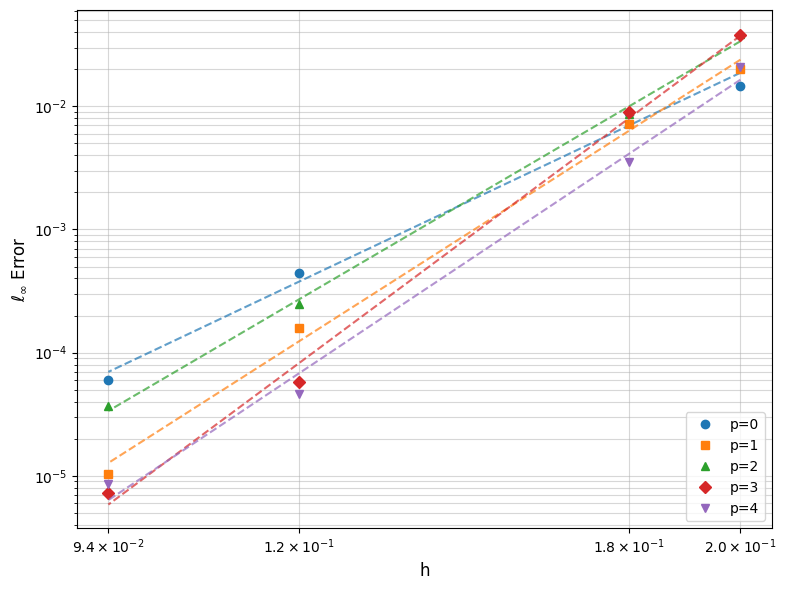

In [53]:
import matplotlib.ticker as ticker
markers = ['o', 's', '^', 'D', 'v']  
colors = ['tab:blue', 'tab:orange', 'tab:green', 'tab:red', 'tab:purple']
labels = [f'p={start_order+0}', f'p={start_order+1}', f'p={start_order+2}', f'p={start_order+3}',f'p={start_order+4}']
plt.figure(figsize=(8, 6))

for i in range(Length):
    h = H[i, :]
    e = E[i, :]
    log_h = np.log(h)
    log_e = np.log(e)
    slope, intercept = np.polyfit(log_h, log_e, 1)
    fit_e = np.exp(intercept) * h**slope
    plt.loglog(h, e, markers[i], color=colors[i], label=f'{labels[i]}')
    plt.loglog(h, fit_e, linestyle='--', color=colors[i], alpha=0.7)

ax = plt.gca()
xticks = np.unique(H.ravel())
xticks = xticks[np.isfinite(xticks)]
xticks = np.sort(xticks)
ax.set_xticks(xticks)
def sci_fmt(x, pos):
    if x == 0:
        return '0'
    exp = int(np.floor(np.log10(x)))
    coeff = x / 10**exp
    return r'$%.1f\times 10^{%d}$' % (coeff, exp)
ax.xaxis.set_major_formatter(ticker.FuncFormatter(sci_fmt))
plt.xlabel('h', fontsize=12)
plt.ylabel(r'$\ell_\infty$ Error', fontsize=12)
ax.xaxis.set_minor_locator(ticker.NullLocator())
plt.grid(True, which="both", ls="-", alpha=0.5)
plt.legend(loc='lower right')
plt.tight_layout()
plt.savefig('./result/helm3d_rfmfd_p=01234_convergence_scatter_overlap_hp.eps', bbox_inches='tight')
plt.show()


In [54]:
# markers = ['o', 's', '^', 'D', 'v']  
# colors = ['tab:blue', 'tab:orange', 'tab:green', 'tab:red', 'tab:purple']
# labels = [f'p={start_order+0}', f'p={start_order+1}', f'p={start_order+2}', f'p={start_order+3}',f'p={start_order+4}']
# plt.figure(figsize=(8, 6))

# for i in range(end_order-start_order):
#     h = H[i, :]
#     e = E[i, :]
#     x = -1.0 / h   # -1/h
#     slope, intercept = np.polyfit(x, np.log(e), 1)
#     fit_e = np.exp(intercept + slope * x)
#     plt.semilogy(
#         x, e,
#         marker=markers[i],
#         linestyle='None',
#         color=colors[i],
#         label=f'{labels[i]}'
#     )
#     plt.semilogy(
#         x, fit_e,
#         linestyle='--',
#         color=colors[i],
#         alpha=0.7,
#         linewidth=1.5
#     )

# ax = plt.gca()
# xticks = -np.unique(1.0 / H.ravel())
# xticks = xticks[np.isfinite(xticks)]
# xticks = np.sort(xticks)
# ax.set_xticks(xticks)

# ax.xaxis.set_major_formatter(ticker.FuncFormatter(lambda x, pos: f"{x:.1f}"))
# plt.xlabel('-1/h', fontsize=12)
# plt.ylabel(r'$\ell_\infty$ Error', fontsize=12)
# ax.xaxis.set_minor_locator(ticker.NullLocator())
# plt.grid(True, which="both", ls="-", alpha=0.5)
# plt.legend(loc='lower right')
# plt.tight_layout()
# plt.savefig('./result/helm3d_rfmfd_p=01234_convergence_scatter_overlap_exp.eps', bbox_inches='tight')
# plt.show()


In [55]:
key = 100
np.random.seed(key)
torch.manual_seed(key)
torch.cuda.manual_seed_all(key)

hidden_size = 50
Phi = PhiNet(input_size=1, hidden_size=hidden_size, output_size=1).to(device) #
Phi.initi()
Phi = Phi.double()

In [56]:
# # NN = [100]
# # BC = [2200] 
# # KK = [180]
# # RR = [1e-15,] # 1.07e-03


# # NN = [200]
# # BC = [4000]
# # KK = [305]    #
# # RR = [1e-14,] # 2.418e-04
# # NN = [200]
# # BC = [4000] 
# # KK = [400] 
# # RR = [1e-15,] 


# # NN = [20, 30, ]
# # BC = [600,800,]
# # KK = [65, 85,]
# # RR = [1e-12,1e-12]

# NN = [20, 30, ]
# BC = [600,800,]
# KK = [65, 90,]
# RR = [1e-12,1e-12]

# order = 0

# for qi, n_local in enumerate(NN):
#     print(f'Run Q={qi+1}, N_local_per_patch={n_local}')
#     N_patch_grid = 5
#     N_local_per_patch = NN[qi]
#     N_boundary = BC[qi]
#     overlap = 0.2

#     # generate points
#     X_inner, X_boundary, C, R, info = generator_points_3d_overlap(
#             N_patch_grid,
#             N_local_per_patch,
#             N_boundary,
#             overlap,
#             False
#         )
#     X = np.vstack([X_inner, X_boundary])
#     Yin = X_inner
#     Yb = X_boundary
#     Y = np.vstack([Yin, Yb])
#     print("fill distance is", info["h"])
#     K = KK[qi]
#     reg = RR[qi]
#     u_true = u_func(Y[:,0:1], Y[:,1:2],Y[:,2:3])
#     if order == 0 :
#         UY,LI,L = rfm_fd_solve_helmholtz_3d(X, Yin, Yb, f_func, g_func,Phi, reg, K)
#     else:
#         UY,LI,L = rfm_fd_poly_solve_helmholtz_3d(X, Yin, Yb, f_func, g_func,Phi, reg, K, order)
#     error = np.max(np.abs(UY - u_true))
#     print(f'p = {order}; L infity error in u_rfmfd: {error.item():.3e}')
#     # E[order-start_order,qi] = error
#     # H[order-start_order,qi] = info["h"]
#     # error_l2 = np.sqrt(np.mean((UY - u_true)**2))
#     # print(f'p = {order}; L2 error in u_rfmfd: {error_l2.item():.3e}')

In [57]:
# order = 0
# row = order - start_order
# x = -np.log10(H[row, :])
# y = -np.log10(E[row, :])
# mask = np.isfinite(x) & np.isfinite(y) & (H[row, :] > 0) & (E[row, :] > 0)
# if np.count_nonzero(mask) >= 2:
#     slope, intercept = np.polyfit(x[mask], y[mask], 1)
#     print(f'slope = {slope:.6f}, bias = {intercept:.6f}')
#     xx = np.linspace(x[mask].min(), x[mask].max(), 100)
#     yy = slope * xx + intercept
#     plt.figure(figsize=(6, 5))
#     plt.plot(x[mask], y[mask], marker='o', linestyle='-', label=f'p={order}')
#     plt.plot(xx, yy, 'r--', label=f'fit: y={slope:.3f}x+{intercept:.3f}')
#     plt.xlabel(r'$-\log_{10}(h)$')
#     plt.ylabel(r'$-\log_{10}(\ell_{\infty}\ \mathrm{error})$')
#     plt.legend()
#     plt.grid(True)
#     plt.show()

# operator learning

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.spatial import cKDTree
from scipy.stats import qmc
# =========================================================
# 1. star-shaped boundary
# =========================================================
def rQ(theta, phi):
    return np.sqrt(
        1
        + np.sin(2 * np.sin(phi) * np.cos(theta))**2
        * np.sin(2 * np.sin(phi) * np.sin(theta))**2
        * np.sin(2 * np.cos(phi))**2
    )
# =========================================================
# 2. inside test
# =========================================================
def inside_star(x, y, z, eps=1e-12):
    r = np.sqrt(x**2 + y**2 + z**2)
    theta = np.arctan2(y, x)
    phi = np.arccos(np.clip(z / (r + eps), -1, 1))
    return r <= rQ(theta, phi)

# =========================================================
# 3. generate boundary points
# =========================================================
def generate_boundary_points(N_boundary=2000):
    sampler = qmc.Halton(d=2, scramble=False)
    pts = sampler.random(N_boundary)
    theta = 2 * np.pi * pts[:, 0]
    phi = np.arccos(1 - 2 * pts[:, 1])
    r = rQ(theta, phi)
    x = r * np.sin(phi) * np.cos(theta)
    y = r * np.sin(phi) * np.sin(theta)
    z = r * np.cos(phi)
    return np.vstack([x, y, z]).T
# =========================================================
# 4. generate patch centers and H
# =========================================================
def generate_centers_auto_H(N_patch_grid, rQ, margin=0.1):
    """
    Returns
    -------
    C    : (N_patch_grid^3, 3)
    H    : scalar, max(Hx, Hy, Hz)
    """
    N_tmp = 20000
    sampler = qmc.Halton(d=2, scramble=False)
    pts = sampler.random(N_tmp)
    theta = 2.0 * np.pi * pts[:, 0]
    phi = np.arccos(1.0 - 2.0 * pts[:, 1])
    r = rQ(theta, phi)
    x = r * np.sin(phi) * np.cos(theta)
    y = r * np.sin(phi) * np.sin(theta)
    z = r * np.cos(phi)
    x_min = x.min() - margin
    x_max = x.max() + margin
    y_min = y.min() - margin
    y_max = y.max() + margin
    z_min = z.min() - margin
    z_max = z.max() + margin
    Hx = (x_max - x_min) / (N_patch_grid - 1)
    Hy = (y_max - y_min) / (N_patch_grid - 1)
    Hz = (z_max - z_min) / (N_patch_grid - 1)
    H = max(Hx, Hy, Hz)
    Cx = np.linspace(x_min, x_max, N_patch_grid)
    Cy = np.linspace(y_min, y_max, N_patch_grid)
    Cz = np.linspace(z_min, z_max, N_patch_grid)
    Xg, Yg, Zg = np.meshgrid(Cx, Cy, Cz, indexing="ij")
    C = np.vstack([Xg.ravel(), Yg.ravel(), Zg.ravel()]).T
    return C, H

def compute_R_from_H_delta(H, delta):
    return (1 + delta) * np.sqrt(3) * H / 2

# =========================================================
# 5. generate inner points via patch + filter
# =========================================================
def generate_inner_points(C, R, N_local):
    X_list = []
    for c in C:
        sampler = qmc.Halton(d=3, scramble=False)
        pts = sampler.random(N_local)
        u, v, w = pts[:, 0], pts[:, 1], pts[:, 2]
        theta = 2 * np.pi * u
        phi = np.arccos(1 - 2 * v)
        r = R * (w ** (1/3))
        x = c[0] + r * np.sin(phi) * np.cos(theta)
        y = c[1] + r * np.sin(phi) * np.sin(theta)
        z = c[2] + r * np.cos(phi)
        X_list.append(np.vstack([x, y, z]).T)
    X_raw = np.vstack(X_list)
    # ======= 关键：投影回 star domain =======
    mask = inside_star(
        X_raw[:, 0],
        X_raw[:, 1],
        X_raw[:, 2]
    )
    X_inner = X_raw[mask]
    return X_inner

def remove_empty_patches_by_Xinner(C_raw, R, X_inner):
    """
    Remove patches that contain no interior points.
    Parameters
    ----------
    C_raw : (Np, 3)
        Patch centers
    R : scalar or (Np,)
        Patch radius
    X_inner : (N, 3)
        Interior points
    Returns
    -------
    C_new : (Np_new, 3)
    R_new : (Np_new,)
    keep  : (Np,) bool mask
    nX    : (Np,) number of points inside each patch
    """
    C_raw = np.asarray(C_raw)
    X_inner = np.asarray(X_inner)
    if np.isscalar(R):
        R_vec = np.full(C_raw.shape[0], R)
    else:
        R_vec = np.asarray(R)
    tree_X = cKDTree(X_inner)
    keep = np.zeros(C_raw.shape[0], dtype=bool)
    nX = np.zeros(C_raw.shape[0], dtype=int)
    for j, c in enumerate(C_raw):
        idx = tree_X.query_ball_point(c, R_vec[j])
        nX[j] = len(idx)
        if nX[j] > 0:
            keep[j] = True
    C_new = C_raw[keep]
    R_new = R_vec[keep]
    print(f"original patches: {C_raw.shape[0]}")
    print(f"kept patches: {C_new.shape[0]}")
    print(f"removed patches: {C_raw.shape[0] - C_new.shape[0]}")
    if np.any(keep):
        print("patch nX min/mean/max:" 
              f"{nX[keep].min()} / {nX[keep].mean():.2f} / {nX[keep].max()}")
    else:
        print("No patches kept!")
    return C_new, R_new, keep, nX
# =========================================================
# 6. 可视化函数
# =========================================================
def visualize_points(X_inner, X_boundary):

    fig = plt.figure(figsize=(8, 8))
    ax = fig.add_subplot(111, projection='3d')
    # ==========================
    # 1. 生成参考边界（仅用于 wireframe）
    # ==========================
    n_theta = 60
    n_phi = 60
    theta = np.linspace(0, 2*np.pi, n_theta)
    phi = np.linspace(0, np.pi, n_phi)
    theta, phi = np.meshgrid(theta, phi)
    r = rQ(theta, phi)
    X = r * np.sin(phi) * np.cos(theta)
    Y = r * np.sin(phi) * np.sin(theta)
    Z = r * np.cos(phi)
    ax.plot_wireframe(
        X, Y, Z,
        rstride=2, cstride=2,
        color='black',
        linewidth=0.5,
        alpha=0.8,
        zorder=0.5
    )
    # ==========================
    # 2. Boundary 点
    # ==========================
    ax.scatter(
        X_boundary[:, 0],
        X_boundary[:, 1],
        X_boundary[:, 2],
        s=1,
        color='blue',
        depthshade=True,
        zorder=2,
        label='Boundary points'
    )
    # ==========================
    # 3. 内点
    # ==========================
    ax.scatter(
        X_inner[::2, 0],
        X_inner[::2, 1],
        X_inner[::2, 2],
        s=1,
        color='red',
        alpha=0.7,
        depthshade=True,
        zorder=3,
        label='Interior points'
    )
    # ==========================
    # 4. 视觉设置
    # ==========================
    ticks = [-1, -0.5, 0, 0.5, 1]
    ax.set_xticks(ticks)
    ax.set_yticks(ticks)
    ax.set_zticks(ticks)
    ax.set_xlim([-1.2, 1.2])
    ax.set_ylim([-1.2, 1.2])
    ax.set_zlim([-1.2, 1.2])
    ax.set_box_aspect([1, 1, 1])
    ax.set_xlabel('x')
    ax.set_ylabel('y')
    ax.set_zlabel('z')
    ax.grid(True, linewidth=0.4, alpha=0.3)
    ax.legend(loc='upper right', fontsize=10)
    ax.view_init(elev=35, azim=45)
    plt.tight_layout()
    plt.show()

# =========================================================
# 7. main
# =========================================================
def generator_points_3d_overlap(
    N_patch_grid,
    N_local_per_patch,
    N_boundary,
    overlap,
    visu
):

    X_boundary = generate_boundary_points(N_boundary)

    # =====================================================
    # 1. raw centers
    # =====================================================
    C_raw, H = generate_centers_auto_H(N_patch_grid, rQ, margin=0.1)
    h = H/(N_local_per_patch)**(1/3)
    info = {
        "H": H ,
        "h": h
            }

    print("Generator's C:", len(C_raw))
    # =====================================================
    # 2. compute R from overlap in 3D
    # =====================================================
    R = compute_R_from_H_delta(H, overlap) # scalar
    print("Generator's R =", R)
    # =====================================================
    # 3. inner points and filter C
    # =====================================================
    X_inner = generate_inner_points(C_raw, R, N_local_per_patch)
    C,R,_,_=remove_empty_patches_by_Xinner(C_raw, R, X_inner)
    print("X_inner:", len(X_inner))
    print("X_boundary:", len(X_boundary))
    # =====================================================
    # 5. visualization
    # =====================================================
    if visu:
        visualize_points(X_inner, X_boundary)

    return X_inner, X_boundary, C, R, info

def fill_distance(nodes):
    """
    nodes: (N, d) numpy array
    returns: scalar h = max_i min_{j != i} ||x_i - x_j||
    """
    nodes = np.asarray(nodes)
    if nodes.shape[0] <= 1:
        return 0.0
    tree = cKDTree(nodes)
    # query 2 nearest (including itself at dist 0), then take second column
    dists, _ = tree.query(nodes, k=2, workers=-1)
    # dists[:,0] == 0, so use dists[:,1]
    min_neigh = dists[:, 1]
    return np.float64(np.max(min_neigh))

#### to make the comparison justified with RFM-FD, make nj = K.  

def estimate_uniform_R_from_target_n(X, target_n, safety=1.1):
    """
    根据目标 patch 内点数 target_n，估计统一半径 R。
    用每个点到第 target_n 个邻居的距离，再取中位数。
    """
    tree = cKDTree(X)
    target_n = min(target_n, X.shape[0])
    dists, _ = tree.query(X, k=target_n, workers=-1)
    if target_n == 1:
        r_each = dists
    else:
        r_each = dists[:, -1]
    R = safety * np.median(r_each)
    return R

def generate_centers_from_R(X, R, delta=0.2, margin=0.1):
    """
    根据统一半径 R 生成规则 Cartesian patch centers。
    3D 中:
        R = (1 + delta) * sqrt(3) * H / 2
    所以:
        H = 2R / ((1 + delta) sqrt(3))
    """
    H = 2.0 * R / ((1.0 + delta) * np.sqrt(3.0))
    xmin, ymin, zmin = X.min(axis=0) - margin
    xmax, ymax, zmax = X.max(axis=0) + margin
    gx = np.arange(xmin, xmax + H, H)
    gy = np.arange(ymin, ymax + H, H)
    gz = np.arange(zmin, zmax + H, H)
    Xg, Yg, Zg = np.meshgrid(gx, gy, gz, indexing="ij")
    C_all = np.vstack([Xg.ravel(), Yg.ravel(), Zg.ravel()]).T
    return C_all, H

def filter_centers_touching_X(C_all, X, R):
    """
    只保留半径 R 内至少包含一个 X 点的 patch center。
    """
    tree_X = cKDTree(X)
    keep = []
    for i, c in enumerate(C_all):
        idx = tree_X.query_ball_point(c, R)
        if len(idx) > 0:
            keep.append(i)
    return C_all[np.array(keep, dtype=int)]


def check_patch_cover_and_counts(C, R, X):
    """
    所以检查所有 X 是否被至少一个 patch 覆盖，
    并统计每个 patch 内点数。
    """
    tree_C = cKDTree(C)
    cover_lists = tree_C.query_ball_point(X, R)
    cover_count = np.array([len(v) for v in cover_lists])
    uncovered = np.where(cover_count == 0)[0]
    tree_X = cKDTree(X)
    nX = np.array([len(tree_X.query_ball_point(c, R)) for c in C])
    print("========== Patch report ==========")
    print("num patches:", len(C))
    print("R =", R)
    print("uncovered X:", len(uncovered), "/", len(X))
    print("cover count min/mean/max:",
          cover_count.min(), cover_count.mean(), cover_count.max())
    print("patch nX min/mean/max:",
          nX.min(), nX.mean(), nX.max())
    return uncovered, cover_count, nX

def generate_patches_X_equals_Y(
    X,
    target_n=120,
    delta=0.2,
    safety=1.1,
    margin=0.1,
    max_iter=10
):
    """
    X=Y 情况下，根据每个 patch 目标点数 target_n 生成 C 和统一 R。
    """
    X = np.asarray(X)
    # 1. 由目标点数估计统一半径
    R = estimate_uniform_R_from_target_n(
        X,
        target_n=target_n,
        safety=safety
    )
    for it in range(max_iter):
        print(f"\n--- iter {it} ---")

        # 2. 由 R 反推中心网格
        C_all, H = generate_centers_from_R(
            X,
            R,
            delta=delta,
            margin=margin
        )
        # 3. 保留和 X 有交集的 patch
        C = filter_centers_touching_X(C_all, X, R)
        # 4. 检查覆盖
        uncovered, cover_count, nX = check_patch_cover_and_counts(C, R, X)
        print("H =", H)
        print("target_n =", target_n)
        print("mean nX / target_n =", nX.mean() / target_n)
        if len(uncovered) == 0:
            break
        # 如果没覆盖完整，扩大半径
        R *= 1.05
    R_vec = R * np.ones(len(C))
    info = {
        "R": R,
        "H": H,
        "delta": delta,
        "num_patches": len(C),
        "target_n": target_n,
        "nX_min": nX.min(),
        "nX_mean": nX.mean(),
        "nX_max": nX.max(),
        "cover_min": cover_count.min(),
        "cover_mean": cover_count.mean(),
        "cover_max": cover_count.max(),
        "uncovered": len(uncovered),
    }
    return C, R_vec, info


def remove_empty_patches(C, R, X_inner, X_boundary):
    """
    去掉球内没有任何 X_inner 或 X_boundary 的 patch centers.
    C: (Np, 3)
    R: (Np,) 或 scalar
    """
    C = np.asarray(C)
    R = np.asarray(R)
    X_all = np.vstack([X_inner, X_boundary])
    tree_X = cKDTree(X_all)
    keep = []
    for j, c in enumerate(C):
        rj = R[j] if R.ndim > 0 else R
        idx = tree_X.query_ball_point(c, rj)
        if len(idx) > 0:
            keep.append(j)
    keep = np.array(keep, dtype=int)
    C_new = C[keep]
    R_new = R[keep] if R.ndim > 0 else R * np.ones(len(C_new))
    print("original patches:", len(C))
    print("kept patches:", len(C_new))
    print("removed patches:", len(C) - len(C_new))
    return C_new, R_new, keep



import numpy as np
import torch
import torch.nn as nn
import scipy.sparse as sp
import scipy.sparse.linalg as spla
from scipy.spatial import KDTree, distance
from scipy.spatial.distance import pdist, squareform
from scipy.sparse import lil_matrix
from scipy.sparse.linalg import spsolve,splu
from scipy.linalg import lstsq
from scipy.sparse import csc_matrix
import matplotlib.ticker as ticker
import time
dtype = torch.float64
device = torch.device('cuda:1' if torch.cuda.is_available() else 'cpu')

def relative_l2(u_pred, u_true):
# Relative L2 error between two (N, 1) tensors.
    eps = 0
    def to_numpy(u):
        if sp.issparse(u):
            u = u.toarray()
        else:
            u = np.asarray(u)
        return u.reshape(-1) # flatten to (N,)
    u_pred,u_true = to_numpy(u_pred),to_numpy(u_true)
    return np.linalg.norm(u_pred - u_true) / (np.linalg.norm(u_true) + eps)


import numpy as np
from scipy.spatial import cKDTree

def fill_distance(nodes):
    """
    nodes: (N, d) numpy array
    returns: scalar h = max_i min_{j != i} ||x_i - x_j||
    """
    nodes = np.asarray(nodes)
    if nodes.shape[0] <= 1:
        return 0.0
    tree = cKDTree(nodes)
    # query 2 nearest (including itself at dist 0), then take second column
    dists, _ = tree.query(nodes, k=2, workers=-1)
    # dists[:,0] == 0, so use dists[:,1]
    min_neigh = dists[:, 1]
    return np.float64(np.max(min_neigh))

class PhiNet(nn.Module):
    def __init__(self, input_size, hidden_size, output_size):
        super(PhiNet, self).__init__()
        self.input_size = input_size
        self.hidden_size = hidden_size
        self.output_size = output_size
        self.input_layer = nn.Linear(input_size, hidden_size, bias = True)
        self.hidden_layer = nn.Linear(hidden_size, hidden_size, bias = True)
        self.output_layer = nn.Linear(hidden_size, output_size, bias = True) 
	
    def forward(self, x): # r : (K,1)  or (K,K)
        K = x.shape[0]
        if x.shape[-1] != self.input_size:
            x = x.view(-1, self.input_size)
        # output = torch.exp(-(2.863822151751348)**2 * x**2)
        output = self.input_layer(x)
        output = torch.sin(output * torch.pi)
        output = torch.cos(self.hidden_layer(output) * torch.pi)
        output = self.output_layer(output)
        if output.shape[0] != K:
            output = output.view(K, -1)
        return output
    
    def initi(self):
        for m in self.modules():
            if isinstance(m, nn.Linear):
                nn.init.xavier_normal_(m.weight)
                if m.bias is not None:
                    nn.init.uniform_(m.bias, 0, 0)
                    # nn.init.uniform_(m.bias, -torch.pi, -torch.pi)

def dphi_wrt_y_3d_batch(phi_net, y, X, eps=1e-8):
    """
    1D Parameters
    ----------
    y : (n_j,3) or (1,3)
    X : (K,3)
    
    Returns
    -------
    phi_vals : (n_j, K)
    dphi_dy  : (n_j, K)
    d2phi_dy2: (n_j, K)
    """
    y = torch.tensor(y, dtype=torch.float64, device=device)
    X = torch.tensor(X, dtype=torch.float64, device=device)
    # print("y.shape", y.shape, "X.shape", X.shape)

    # =========================================================
    # 1. pairwise difference and Euclidean distance
    # =========================================================
    diff = y[:, None, :] - X[None, :, :]          # (n_j, K, 3)
    r = torch.sqrt((diff ** 2).sum(dim=-1))  # (n_j, K)
    r = r.clamp(min=eps)  
    r.requires_grad_(True)
    # -------- forward --------
    phi_vals = phi_net(r)         # (n_j, K)

    # -------- φ'(r) --------
    dphi_dr = torch.autograd.grad(
        outputs=phi_vals,
        inputs=r,
        grad_outputs=torch.ones_like(phi_vals),
        create_graph=True
    )[0]   # (n_j, K)
    grad_phi = dphi_dr[..., None] * diff / (r[..., None])
    # -------- φ''(r) --------
    d2phi_dr2 = torch.autograd.grad(
        outputs=dphi_dr,
        inputs=r,
        grad_outputs=torch.ones_like(dphi_dr),
        create_graph=False
    )[0]   # (n_j, K)
    # 3d laplace
    lap_phi = d2phi_dr2 + (2.0 / (r)) * dphi_dr

    return (
        phi_vals.detach().cpu().numpy(),
        grad_phi.detach().cpu().numpy(),
        lap_phi.detach().cpu().numpy()
    )

def poly3D(Z, order):
    """
    Z: (K, d)
    P: (K, Norder); 
    """
    K = Z.shape[0]
    Norder = (order + 1) * (order + 2) * (order + 3) // 6
    P = np.zeros((K, Norder))
    powers = np.arange(order + 1)
    X_pow = Z[:, 0:1] ** powers
    Y_pow = Z[:, 1:2] ** powers
    Z_pow = Z[:, 2:3] ** powers
    cnt = 0
    for i in range(order + 1):
        for j in range(order - i + 1):
            for k in range(order - i - j + 1):
                P[:, cnt] = X_pow[:, i] * Y_pow[:, j] * Z_pow[:, k]
                cnt += 1        
    return P


def laplacian_poly3D(y, order):
    """
    y: (Np, d)
    lap: (Norder, Np); 
    """
    Np = y.shape[0]
    Norder = (order + 1) * (order + 2) * (order + 3) // 6
    lap = np.zeros((Norder, Np))
    
    # 【核心优化】：同样预先计算 0 到 order 的所有幂次
    powers = np.arange(order + 1)
    X_pow = y[:, 0:1] ** powers
    Y_pow = y[:, 1:2] ** powers
    Z_pow = y[:, 2:3] ** powers
    curr = 0
    for i in range(order + 1):
        for j in range(order - i + 1):
            for k in range(order - i - j + 1):
                val = np.zeros(Np)
                if i >= 2:
                    val += (i * (i - 1)) * (X_pow[:, i - 2] * Y_pow[:, j] * Z_pow[:, k])
                if j >= 2:
                    val += (j * (j - 1)) * (X_pow[:, i] * Y_pow[:, j - 2] * Z_pow[:, k])
                if k >= 2:
                    val += (k * (k - 1)) * (X_pow[:, i] * Y_pow[:, j] * Z_pow[:, k - 2]) 
                lap[curr, :] = val
                curr += 1     
    return lap


In [2]:
import scipy.sparse as sp
import scipy.sparse.linalg as spla
from scipy.sparse.linalg import spsolve

def build_wls_solver(A, reg=1e-12):
    """
    Precompute WLS system for repeated RHS solves.
    solve_A = build_wls_solver(A)
    alpha = solve_A(RHS)
    """
    if not sp.isspmatrix(A):
        raise TypeError("A must be a scipy sparse matrix")
    A = A.tocsr()
    M, N = A.shape
    # -------------------------------------------------
    # weight (computed ONCE)
    # -------------------------------------------------
    row_max = np.abs(A).max(axis=1).toarray().ravel()
    w = 10.0 / (row_max + 1e-12)
    W = sp.diags(w, format='csr')
    # -------------------------------------------------
    # precompute matrices
    # -------------------------------------------------
    Aw = W @ A
    AtA = Aw.T @ Aw + reg * sp.eye(N, format='csr')

    # factorization (FAST SOLVE)
    solver = spla.factorized(AtA.tocsc())

    # -------------------------------------------------
    # return closure
    # -------------------------------------------------
    def solve(RHS):
        """
        RHS: (M,K)
        """
        RHS = np.asarray(RHS, dtype=np.float64)

        if RHS.ndim == 1:
            RHS = RHS[:, None]

        # weighted RHS
        RHSw = w[:, None] * RHS

        Atb = Aw.T @ RHSw
        x = solver(Atb)
        if x.ndim == 1:
            x = x[:, None]
        return x
    return solve

def rfm_fd_poly_solve_helmholtz_3d(X, Yin, Yb, f_func, g_func,Phi, reg, K, order):
    """
    -Laplace(u) - k^2 u = f, where k^2 = 1
    X:  (N,3)  RBF source points
    Yin: (M1,3) interior points
    Yb:  (M2,3) boundary points
    f_func, g_func: Python callable returning torch tensor
    K: number of neighbors
    order: 0,1,2,3...
    """
    N = X.shape[0]
    M1 = Yin.shape[0]
    M2 = Yb.shape[0]
    M = M1 + M2
    Y = np.vstack((Yin, Yb))
    Norder = (order + 1) * (order + 2) * (order + 3) // 6

    tree = KDTree(X)
    dist, idx = tree.query(Y, k=K, workers=-1)
    
    f_val =f_func(Yin[:, 0], Yin[:, 1], Yin[:, 2])  if callable(f_func) else f_func #(M1,)
    g_val = g_func(Yb[:, 0], Yb[:, 1], Yb[:, 2]) if callable(g_func) else g_func
    RHS = np.concatenate((f_val, g_val)) #(M,)
    # print("RHS.shape",RHS.shape)
    L = lil_matrix((M, N))
    LI = lil_matrix((M, N))
    O = np.zeros((Norder,Norder))
    # ==============================
    # main loop
    # ==============================
    diff_XX = X[:,None,:] - X[None,:,:]
    dist_XX = np.sqrt((diff_XX**2).sum(-1)) # (N,N)
    start = time.time()
    for i in range(M):
        y = Y[i, :][None,:]
        idx_l = idx[i, :]
        Z = X[idx_l, :]
        dist_ZZ = dist_XX[np.ix_(idx_l,idx_l)]
        dist_ZZ = torch.as_tensor(dist_ZZ, dtype = torch.float64, device = device)
        Phi_jj = Phi(dist_ZZ)
        Phi_jj = Phi_jj.detach().cpu().numpy()
        phi_xj, grad_phi, lap_phi  = dphi_wrt_y_3d_batch(Phi, y, Z, eps=1e-8) # (1,K),(1,K,3),(1,K),
        # print("phi_xj",phi_xj.shape,"lap_phi",lap_phi.shape, "grad_phi",grad_phi.shape)
        # AP
        P = poly3D(Z, order) # (K,Norder)
        AP = np.block([
            [Phi_jj, P],
            [P.T, O]
        ])
        # RHS_lap, RHS_ide
        p_y = poly3D(y, order)               # (1,Norder)
        lap_p = laplacian_poly3D(y, order)   # (Norder,1)
        # print("p_y.shape",p_y.shape, "lap_p",lap_p.shape)
        RHS_lap = np.concatenate((lap_phi, lap_p.T), axis = 1).T  # (K+Norder,1)
        # print(RHS_lap.shape)
        RHS_ide = np.concatenate((phi_xj, p_y), axis = 1).T       # (K+Norder,1)
        RHS_all = np.concatenate((RHS_lap, RHS_ide),axis=1)       # (K+Norder,2)
        #
        # w_all = np.linalg.solve(AP, RHS_all).T                    # (2, K+Norder)
        w_all = lstsq(AP, RHS_all, cond=None)[0].T
        w_lap = w_all[0, :]
        w_ide = w_all[1, :]
        
        if i < M1: 
            L[i, idx_l] = -w_lap[:K] - w_ide[:K]
            LI[i, idx_l] = w_ide[:K]
        else:
            L[i, idx_l] = w_ide[:K]
            LI[i, idx_l] = w_ide[:K]

    end = time.time()
    print("Compile derivative matrix time =", end - start, "seconds")
        
    L = L.tocsc()
    LI = LI.tocsc()
    # ==============================
    # solve
    # ==============================
    if M == N:
        LU = splu(L, permc_spec='COLAMD')
        UX = LU.solve(RHS)
    else:
        if M < N:
            print("Warning: underdetermined system M < N")
        # least squares: solve column by column
        solve_L = build_wls_solver(L, reg = 1e-12)
        UX = solve_L(RHS).squeeze(-1)
        # print(UX.shape)
    UY = LI @ UX

    return UY[:,None],LI,L



def test_solver(L, LI, RHS):
    """
    L  : (M,N) sparse operator matrix
    LI : (M,N) sparse interpolation matrix
    RHS: (M,Q) numpy array

    Returns
    -------
    UY : (M,Q) numpy array
    """
    L = L.tocsr()
    LI = LI.tocsr()

    M, N = L.shape
    Q = RHS.shape[1]
    # -------------------------
    # Solve L UX = RHS
    # -------------------------
    if M == N:
        # spsolve supports multiple RHS
        UX = spsolve(L, RHS)          # (N,Q)
    else:
        # least squares: solve column by column
        solve_L = build_wls_solver(L)
        UX = solve_L(RHS) # (N,Q)
        print(UX.shape)
        # Q, R = np.linalg.qr(L.toarray(), mode='reduced')
        # UX = np.linalg.solve(R, Q.T @ RHS)
    # -------------------------
    # Evaluate at Y
    # -------------------------
    UY = LI @ UX # (M,Q)

    return UY


In [3]:
key = 100
np.random.seed(key)
torch.manual_seed(key)
torch.cuda.manual_seed_all(key)

hidden_size = 50
Phi = PhiNet(input_size=1, hidden_size=hidden_size, output_size=1).to(device) #
Phi.initi()
Phi = Phi.double()

u_func = lambda x, y, z: np.sin(np.pi * x) * np.sin(np.pi * y) * np.sin(np.pi * z)
g_func = lambda x, y, z: u_func(x, y, z)
# #===========================================================
data = np.load('./data/orig_nodes_results_on_X_generated_by_overlap.npz') #coords, interior_idx, boundary_idx, u_new, f_new  


p, f_new, u_new, index_in, index_bc = data['coords'],data['f_new'],data['u_new'],data['interior_idx'],data['boundary_idx']  # sigma2 = 0.1, l = 0.15
index_in, index_bc = index_in.reshape(-1), index_bc.reshape(-1)
# print(index_in)
# print(p.shape,f_new.shape) # (21523, 3) (21523, 100)
# print(index_in.shape, index_bc.shape) #(11142,) (10381,)

torchdtype = torch.float64
Y = p
M = Y.shape[0]
M2 = index_bc.shape[0]
M1 = M - M2

testnum = 0
Yin,Yb = Y[index_in,:],Y[index_bc,:] # interior and boundary points
f_func = f_new[index_in,testnum]
print("f_func.shape",f_func.shape)


u_true = u_new[:,testnum]
u_true = np.concatenate([u_true[index_in,None],u_true[index_bc,None]],axis=0)
print("u_true's shape",u_true.shape)
# #===========================================================
# #==================== Source points X ====================
# #===========================================================
torchdtype = torch.float64
N_patch_grid = 5
N_local_per_patch = 150
N_boundary = 3000
overlap = 0.2

# generate points
X_inner, X_boundary, C, R, info = generator_points_3d_overlap(
        N_patch_grid,
        N_local_per_patch,
        N_boundary,
        overlap,
        False
    )
X = np.vstack([X_inner, X_boundary])

K = 200
reg = 1e-13# (qr donot need this, better than LU)
order = 3

# # ===========================================================
start = time.time()
UY,LI,L = rfm_fd_poly_solve_helmholtz_3d(X, Yin, Yb, f_func, g_func, Phi, reg, K, order)
end = time.time()
print("Time for solving Helm =", end - start, "seconds")
print(u_true.shape,UY.shape)
error = np.abs(UY- u_true)[:M1,:] 
error_bc = np.abs(UY- u_true)[M1:,:]
print(f"error on boundary is  {error_bc.max().item():.3e}")
print(f'p = {order}; L infity error in u_rfmfd: {error.max().item():.3e}')
error_u = relative_l2(UY[:M1,:] ,u_true[:M1,:])
print(f'p = {order}; Relative L2 error in u_rfmfd: {error_u.item():.3e}')
# sin

f_func.shape (9031,)
u_true's shape (15031, 1)
Generator's C: 125
Generator's R = 0.5715535913334557
original patches: 125
kept patches: 112
removed patches: 13
patch nX min/mean/max:1 / 211.67 / 752
X_inner: 4699
X_boundary: 3000
Compile derivative matrix time = 84.11995220184326 seconds
Time for solving Helm = 110.44259309768677 seconds
(15031, 1) (15031, 1)
error on boundary is  2.301e-04
p = 3; L infity error in u_rfmfd: 8.272e-03
p = 3; Relative L2 error in u_rfmfd: 1.237e-02


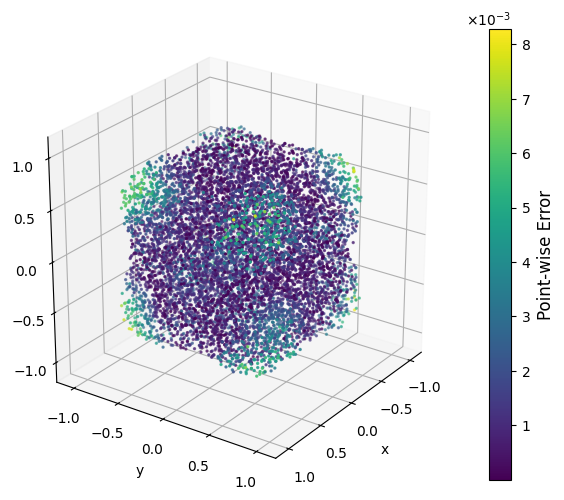

In [4]:
fig = plt.figure(figsize=(6,5))
ax = fig.add_subplot(111, projection='3d')
ticks = [-1, -0.5, 0, 0.5, 1]
ax.set_xticks(ticks)
ax.set_yticks(ticks)
ax.set_zticks(ticks)
ax.set_xlim([-1.2, 1.2])
ax.set_ylim([-1.2, 1.2])
ax.set_zlim([-1.2, 1.2])
ax.set_box_aspect([1, 1, 1])
sc = ax.scatter(
    Y[:M1, 0], Y[:M1, 1], Y[:M1, 2],
    c=error[:,:],
    cmap='viridis',
    s=2
)
cbar = plt.colorbar(sc)
cbar.set_label('Point-wise Error', fontsize=12)
formatter = ticker.ScalarFormatter(useMathText=True)
formatter.set_scientific(True)
formatter.set_powerlimits((0, 0))
cbar.ax.yaxis.set_major_formatter(formatter)
plt.xlabel('x')
plt.ylabel('y')
ax.set_zlabel('z')
ax.view_init(elev=25, azim=35)
plt.tight_layout()
plt.show()

In [5]:
import time
E_inf, E_L2 = np.zeros((100,1)),np.zeros((100,1))
Yin,Yb = Y[index_in,:],Y[index_bc,:] # interior and boundary points
f_vec = f_new[index_in,:] 
g_vec = u_new[index_bc,:]

u_true = u_new
u_true = np.concatenate([u_true[index_in,:],u_true[index_bc,:]],axis=0)
print(u_true.shape, f_vec.shape, g_vec.shape)
RHS = np.concatenate([f_vec,g_vec],axis = 0 )

start_time = time.time()
UY = test_solver(L, LI, RHS)
end_time = time.time()
print(f"p = {order}, inference time: {end_time - start_time:.4f} 秒")

error_inf = np.abs(UY - u_true)
E_inf =  np.max(error_inf,axis = 0)
error_L2 = np.linalg.norm(UY - u_true, axis = 0) / np.linalg.norm(u_true, axis =0)
E_L2 = error_L2

avg_inf = np.mean(E_inf)
avg_L2 = np.mean(E_L2)
var_inf = np.var(E_inf)
var_L2 = np.var(E_L2)

np.random.seed(100)
q = np.random.randint(0,100)

import matplotlib.colors as mcolors

v_min = min(u_true[:, q].min(), UY[:, q].min())
v_max = max(u_true[:, q].max(), UY[:, q].max())
norm = mcolors.Normalize(vmin=v_min, vmax=v_max)

(15031, 100) (9031, 100) (6000, 100)


(7699, 100)
p = 3, inference time: 35.4800 秒


The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


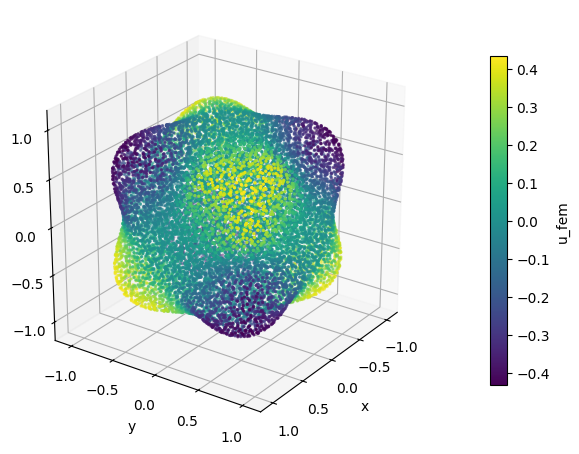

The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


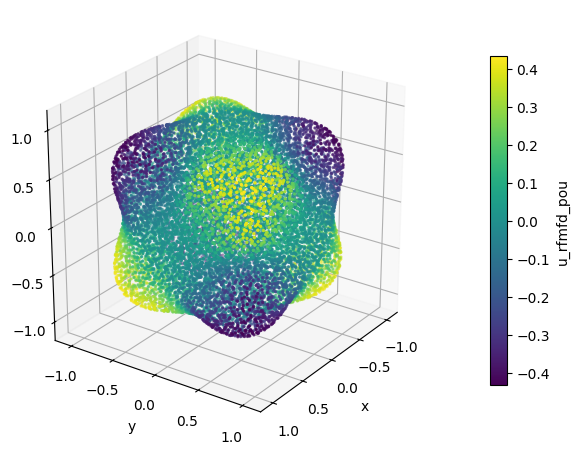

The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


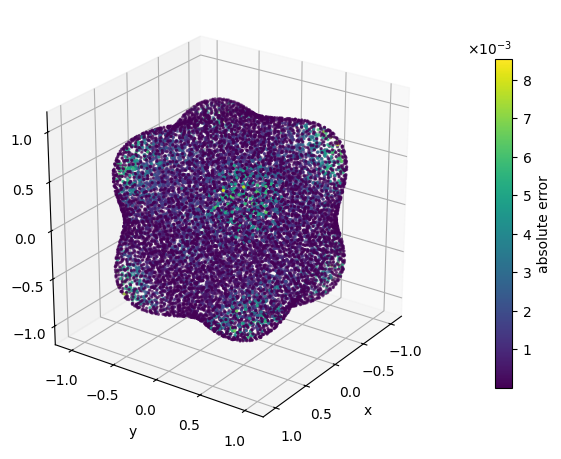

p = 3, test on 100 samples. The mean of max error: 8.345891e-03, and mean of relative L2 error: 8.167874e-03
p = 3, test on 100 samples. The variance of max error: 2.787338e-08, and variance of relative L2 error: 1.471333e-07


In [6]:
# plot_3d_scalar
# u_fem

fig = plt.figure(figsize=(6, 5))
ax = fig.add_subplot(111, projection='3d')
ticks = [-1, -0.5, 0, 0.5, 1]
ax.set_xticks(ticks)
ax.set_yticks(ticks)
ax.set_zticks(ticks)
ax.set_xlim([-1.2, 1.2])
ax.set_ylim([-1.2, 1.2])
ax.set_zlim([-1.2, 1.2])
ax.set_box_aspect([1, 1, 1])
sc = ax.scatter(
    Y[:, 0], Y[:, 1], Y[:, 2],
    c=u_true[:, q].reshape(-1),
    cmap='viridis',
    s=2
)
cbar = fig.colorbar(sc, ax=ax, shrink=0.7, pad=0.1)
cbar.set_label('u_fem')
ax.set_xlabel('x')
ax.set_ylabel('y')
ax.set_zlabel('z')
ax.view_init(elev=25, azim=35)
plt.tight_layout()
fig.savefig(f'./result/helm3d_rfmfd_p={order}_u_fem.eps', bbox_inches='tight')
plt.show()

# u_rfmfd_pou
fig = plt.figure(figsize=(6, 5))
ax = fig.add_subplot(111, projection='3d')
ticks = [-1, -0.5, 0, 0.5, 1]
ax.set_xticks(ticks)
ax.set_yticks(ticks)
ax.set_zticks(ticks)
ax.set_xlim([-1.2, 1.2])
ax.set_ylim([-1.2, 1.2])
ax.set_zlim([-1.2, 1.2])
ax.set_box_aspect([1, 1, 1])
sc = ax.scatter(
    Y[:, 0], Y[:, 1], Y[:, 2],
    c=UY[:, q].reshape(-1),
    cmap='viridis',
    s=2
)
cbar = fig.colorbar(sc, ax=ax, shrink=0.7, pad=0.1)
cbar.set_label('u_rfmfd_pou')
ax.set_xlabel('x')
ax.set_ylabel('y')
ax.set_zlabel('z')
ax.view_init(elev=25, azim=35)
plt.tight_layout()
fig.savefig(f'./result/helm3d_rfmfd_p={order}_u_rfm_fd.eps',bbox_inches='tight')
plt.show()

# absolute error
error_inf = np.abs(UY - u_true)
fig = plt.figure(figsize=(6, 5))
ax = fig.add_subplot(111, projection='3d')
ticks = [-1, -0.5, 0, 0.5, 1]
ax.set_xticks(ticks)
ax.set_yticks(ticks)
ax.set_zticks(ticks)
ax.set_xlim([-1.2, 1.2])
ax.set_ylim([-1.2, 1.2])
ax.set_zlim([-1.2, 1.2])
ax.set_box_aspect([1, 1, 1])
sc = ax.scatter(
    Y[:, 0], Y[:, 1], Y[:, 2],
    c=error_inf[:, q].reshape(-1),
    cmap='viridis',
    s=2
)
cbar = fig.colorbar(sc, ax=ax, shrink=0.7, pad=0.1)
cbar.set_label('absolute error')
formatter = ticker.ScalarFormatter(useMathText=True)
formatter.set_scientific(True)
formatter.set_powerlimits((0, 0))
cbar.ax.yaxis.set_major_formatter(formatter)
ax.set_xlabel('x')
ax.set_ylabel('y')
ax.set_zlabel('z')
ax.view_init(elev=25, azim=35)
plt.tight_layout()
fig.savefig(f'./result/helm3d_rfmfd_p={order}_absolute_error.eps', bbox_inches='tight')
plt.show()
print(f"p = {order}, test on 100 samples. The mean of max error: {avg_inf:3e}, and mean of relative L2 error: {avg_L2:3e}")
print(f"p = {order}, test on 100 samples. The variance of max error: {var_inf:3e}, and variance of relative L2 error: {var_L2:3e}")
